# Car fuels — diesel: weekly BVAR-SV-outlier

This notebook estimates the **diesel** weekly sub-model of the euro-area
energy-inflation suite. The endogenous block contains weekly absolute changes in
the WOB diesel pre-tax price, crude oil and refined diesel prices. The model
uses **24 weekly lags**, stochastic volatility and model-based transitory outliers.

The weekly calendar is Monday–Sunday and labelled by Monday. Commodity information
aligned to WOB Monday $t$ comes from the preceding completed commodity week, avoiding
post-Monday information. Interior WOB non-publication weeks remain missing in the raw
panel and are drawn **inside every Gibbs sweep** by Durbin–Koopman data augmentation;
no deterministic interpolation is used. Builder-flagged incomplete final Bloomberg
aggregates are temporarily masked to `NaN` until the positive-`obs_cov` measurement
model is implemented.

$$
y_t = c + \sum_{\ell=1}^{24} B_\ell y_{t-\ell} + \nu_t,
\qquad
\nu_t=A^{-1}O_t\Lambda_t^{1/2}\varepsilon_t.
$$


## 1. Imports and configuration

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]
for candidate in MODEL_DIR_CANDIDATES:
    required_modules = (
        "energy_bvar_model.py",
        "energy_bvar_weekly_fuels.py",
        "energy_bvar_plot.py",
        "energy_bvar_io.py",
    )
    if all((candidate / name).exists() for name in required_modules):
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Place energy_bvar_model.py, energy_bvar_weekly_fuels.py, "
        "energy_bvar_plot.py and energy_bvar_io.py in src/model/."
    )

from energy_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    coefficient_posterior_tables,
    forecast_bvar_sv_outlier,
    forecast_error_variance_decomposition,
    historical_decomposition,
    impulse_responses,
    make_bvar_svo_prior,
    mcmc_diagnostics,
    nowcast_summary_table,
    posterior_outlier_probability,
    posterior_predictive_statistics,
    posterior_completed_differences,
    prepare_bvar_panel,
    residual_diagnostic_table,
    run_energy_bvar,
    stability_diagnostics,
    stationarity_tests,
)
from energy_bvar_io import save_energy_bvar_result
from energy_bvar_weekly_fuels import (
    load_weekly_fuel_panel,
    load_weekly_tax_context,
    reattribute_weekly_taxes,
    weekly_forecast_horizon_table,
    weekly_fuel_series_construction_table,
    weekly_partial_period_table,
    weekly_fuel_spec,
    weekly_paths_to_monthly_mean,
)
from energy_bvar_plot import (
    plot_absolute_differences,
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_data_levels,
    plot_fevd,
    plot_forecast_comparison,
    plot_historical_decomposition,
    plot_impulse_responses,
    plot_minnesota_prior_by_equation,
    plot_nowcast_fan,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_short_forecast_fan,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    plot_volatility_decomposition,
    style_numeric_table,
)

pd.set_option("display.max_rows", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 190)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

MODEL = "diesel"
SPEC = weekly_fuel_spec(MODEL)
COMPONENT = "car_fuels_diesel"
SEED = 42
P = 24
VARIABLES = SPEC["variables"]
TARGET = SPEC["target"]
UNITS = SPEC["units"]
SAVE_RESULTS = False
RESULTS_ROOT = PROJECT_ROOT / "results"

# Only used for automated smoke tests. Normal research runs keep the paper setup.
FAST_MODE = os.getenv("ENERGY_BVAR_FAST_TEST", "0") == "1"
FORECAST_H = 8 if FAST_MODE else 26
FORECAST_DRAWS = 10 if FAST_MODE else 500
PPC_DRAWS = 10 if FAST_MODE else 200
STRUCTURAL_DRAWS = 10 if FAST_MODE else 300

print(f"Project root: {PROJECT_ROOT}")
print(f"Model modules: {MODEL_DIR}")
print(f"Model: {SPEC['label']}")
print(f"Fast test mode: {FAST_MODE}")

Project root: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Model modules: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model
Model: Car fuels — diesel
Fast test mode: False


## 2. Data

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260807\car_fuels_weekly.csv
Sample calendar: 2005-01-03 to 2026-08-10
Rows: 1,128; all dates Monday: True


,model_unit,source,construction,weekly_alignment,commodity_shift_weeks
series,,,,,
wob_diesel_pre_tax,"EUR per 1,000 litres",European Commission Weekly Oil Bulletin,"Official pre-tax consumer price, Monday observation",Monday WOB date,—
crude_oil_eur,EUR per barrel,Bloomberg crude oil and EUR/USD,"Daily USD/barrel converted to EUR/barrel, then weekly mean",shift=1 aligns WOB Monday t with the preceding completed Monday-Sunday commodity week; shift=0 aligns it with the same week and therefore includes post-Monday quotations.,1.00
refined_diesel_eur,EUR per barrel,Bloomberg refined-product future and EUR/USD,"Daily USD/metric-tonne quote converted with 7.44 barrels per tonne and EUR/USD, then weekly mean",shift=1 aligns WOB Monday t with the preceding completed Monday-Sunday commodity week; shift=0 aligns it with the same week and therefore includes post-Monday quotations.,1.00


,series,panel_column,panel_label_date,final_period_input_observations,expected_input_observations,coverage_ratio,final_period_complete,first_input_date,last_input_date
0,crude_oil_eur,crude_oil_eur,2026-08-10,1.00,5.00,0.20,0.00,2026-08-03,2026-08-03
1,refined_diesel_eur,refined_diesel_eur,2026-08-10,1.00,5.00,0.20,0.00,2026-08-03,2026-08-03


,panel_column,panel_label_date,coverage_ratio,original_value,policy
0,crude_oil_eur,2026-08-10,0.20,72.23,temporary partial-period mask pending obs_cov measurement model
1,refined_diesel_eur,2026-08-10,0.20,137.50,temporary partial-period mask pending obs_cov measurement model


,wob_diesel_pre_tax,crude_oil_eur,refined_diesel_eur
date,,,
2026-05-25,1136.63,88.76,136.98
2026-06-01,1095.59,79.94,120.93
2026-06-08,1068.50,81.79,125.90
2026-06-15,1047.33,78.66,119.73
2026-06-22,984.54,69.32,105.08
2026-06-29,972.50,66.19,104.76
2026-07-06,964.24,64.07,109.26
2026-07-13,1017.49,66.34,120.74
2026-07-20,1103.26,74.34,133.77


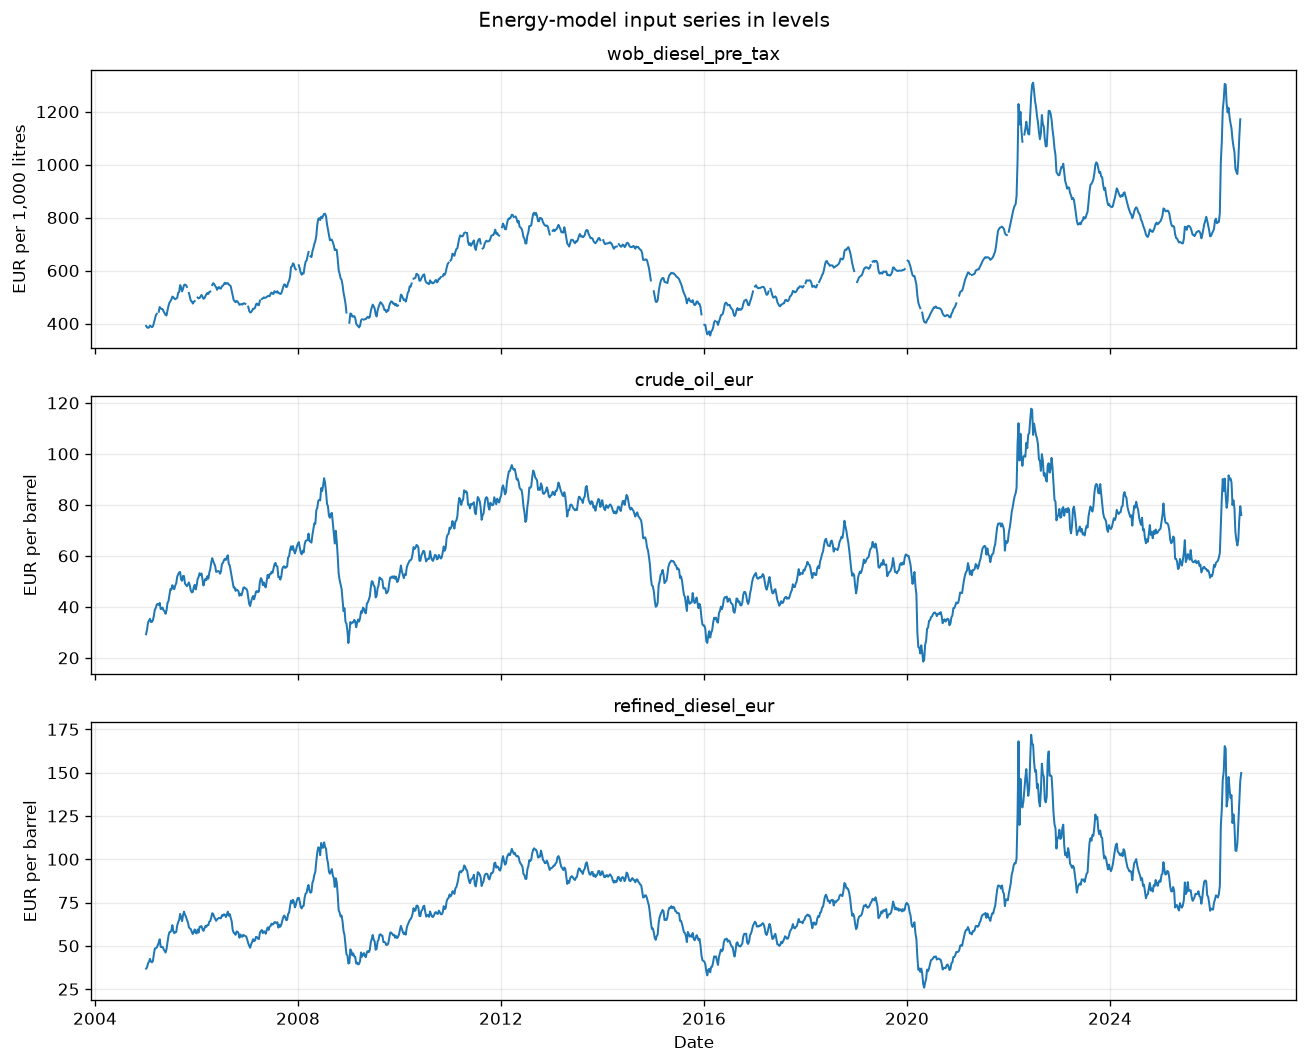

In [2]:
# Set VINTAGE = "YYYYMMDD" to force one processed vintage.
VINTAGE = None
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

if VINTAGE is None:
    candidates = sorted(
        path
        for path in PROCESSED_ROOT.glob(f"*/{SPEC['dataset']}")
        if path.is_file()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No {SPEC['dataset']} found below {PROCESSED_ROOT}."
        )
    COMPONENT_DATASET = candidates[-1]
else:
    COMPONENT_DATASET = PROCESSED_ROOT / VINTAGE / SPEC["dataset"]

levels = load_weekly_fuel_panel(COMPONENT_DATASET, model=MODEL)

print(f"Dataset: {COMPONENT_DATASET}")
print(f"Sample calendar: {levels.index.min().date()} to {levels.index.max().date()}")
print(f"Rows: {len(levels):,}; all dates Monday: {(levels.index.dayofweek == 0).all()}")

display(style_numeric_table(
    weekly_fuel_series_construction_table(COMPONENT_DATASET, MODEL),
    caption="Construction of the weekly diesel-model level series",
))
coverage_table = weekly_partial_period_table(COMPONENT_DATASET, MODEL)
if not coverage_table.empty:
    display(style_numeric_table(
        coverage_table,
        caption="Final-period aggregation coverage (builder sidecar)",
    ))

partial_mask = levels.attrs.get("partial_period_mask", pd.DataFrame())
if isinstance(partial_mask, pd.DataFrame) and not partial_mask.empty:
    display(style_numeric_table(
        partial_mask,
        caption="Partial final aggregates masked to NaN before BVAR estimation",
    ))

display(style_numeric_table(
    levels.tail(12),
    caption="Latest processed weekly levels after adapter masking",
))
plot_data_levels(levels, units=UNITS)
plt.show()

The endogenous vector is ordered from the consumer price upstream through the
commodity chain:

$$
y_t=
\begin{bmatrix}
\Delta P_t^{\mathrm{diesel,pre\ tax}}\\
\Delta P_t^{\mathrm{crude}}\\
\Delta P_t^{\mathrm{refined\ diesel}}
\end{bmatrix},
\qquad \Delta x_t=x_t-x_{t-1}.
$$

No log transformation and no seasonal dummy are used in this weekly equation.
The observed-level state equation treats published weeks exactly; missing WOB weeks
inside the estimation sample are latent and are redrawn in each Gibbs iteration.


,value
frequency,weekly
calendar_rule,W-MON
estimation_mode,Durbin-Koopman interior data augmentation
companion_warmup_start,2005-04-11 00:00:00
augmentation_anchor,2005-09-19 00:00:00
estimation_end,2026-07-27 00:00:00
VAR_regression_observations,1088
regression_columns_per_equation,73
interior_missing_dates,48
interior_missing_level_cells,48


""
date
2005-10-31
2005-12-26
2006-01-02
2006-04-17
2006-12-25
2007-01-01
2007-04-09
2007-12-24
2007-12-31


,wob_diesel_pre_tax,crude_oil_eur,refined_diesel_eur
date,,,
2026-08-03,—,-3.47,4.42
2026-08-10,—,—,—


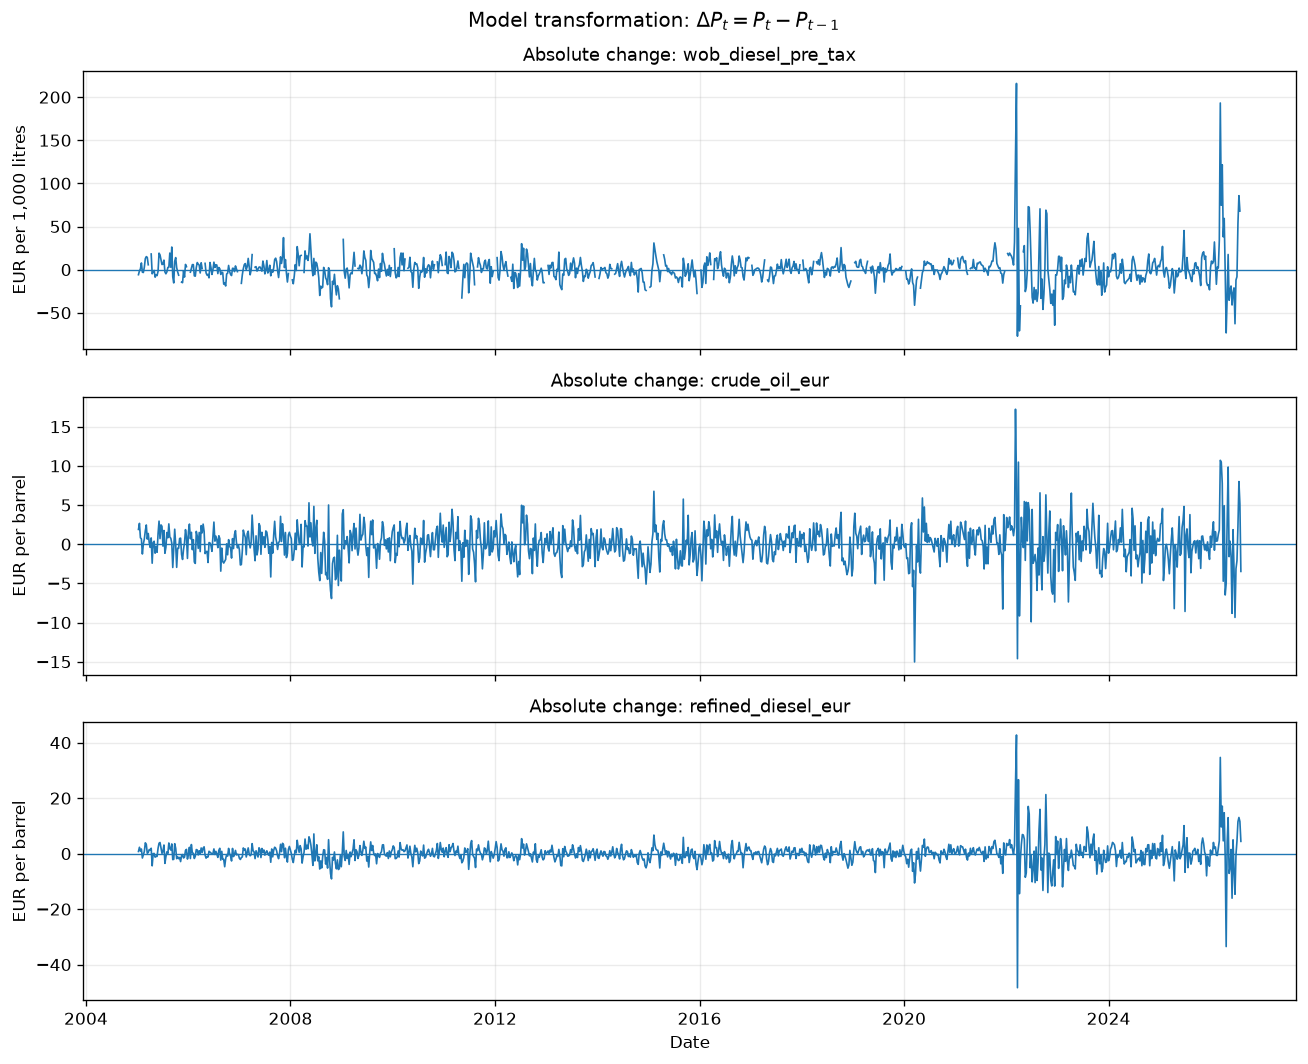

In [3]:
prep = prepare_bvar_panel(
    levels,
    p=P,
    variables=VARIABLES,
    frequency="weekly",
)

transformation_summary = pd.Series({
    "frequency": prep["frequency"],
    "calendar_rule": prep["calendar_rule"],
    "estimation_mode": (
        "Durbin-Koopman interior data augmentation"
        if prep.get("requires_data_augmentation", False)
        else "balanced sample"
    ),
    "companion_warmup_start": prep["balanced_start"],
    "augmentation_anchor": prep.get("augmentation_anchor", "not required"),
    "estimation_end": prep["balanced_end"],
    "VAR_regression_observations": prep["n_regression_observations"],
    "regression_columns_per_equation": prep["k"],
    "interior_missing_dates": prep.get("n_interior_missing_dates", 0),
    "interior_missing_level_cells": prep.get("n_interior_missing_level_cells", 0),
    "ragged_edge_weeks": prep["n_ragged_periods"],
    "latest_calendar_week": prep["last_calendar_date"],
})
display(style_numeric_table(
    transformation_summary.to_frame("value"),
    caption="Transformation and estimation sample",
))

if prep.get("requires_data_augmentation", False):
    missing_dates = pd.DataFrame({
        "date": prep["interior_missing_dates"],
    }).set_index("date")
    display(style_numeric_table(
        missing_dates,
        caption="Interior weeks entering the Gibbs sampler as latent states",
    ))

display(style_numeric_table(
    prep["ragged"],
    caption="Ragged-edge absolute weekly changes",
))
plot_absolute_differences(prep["differences"], units=UNITS)
plt.show()


## 3. Priors

,value,interpretation
lambda1,0.20,overall Minnesota lag tightness
lambda2,0.50,additional cross-lag tightness
lambda3,1.00,lag-decay exponent
lambda4,10.00,constant prior scale
A prior variance,10.00,variance of each free contemporaneous A coefficient
phi prior mean,0.02,prior mean of volatility-of-volatility variance
outlier alpha,2.50,Beta outlier pseudo-count
outlier beta,117.50,Beta regular-observation pseudo-count


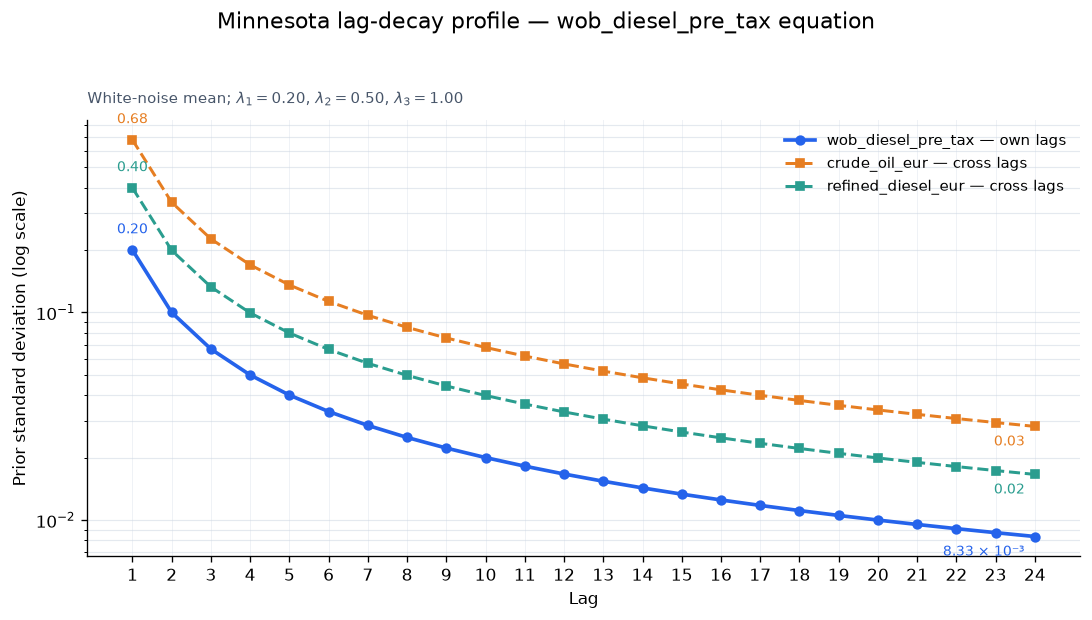

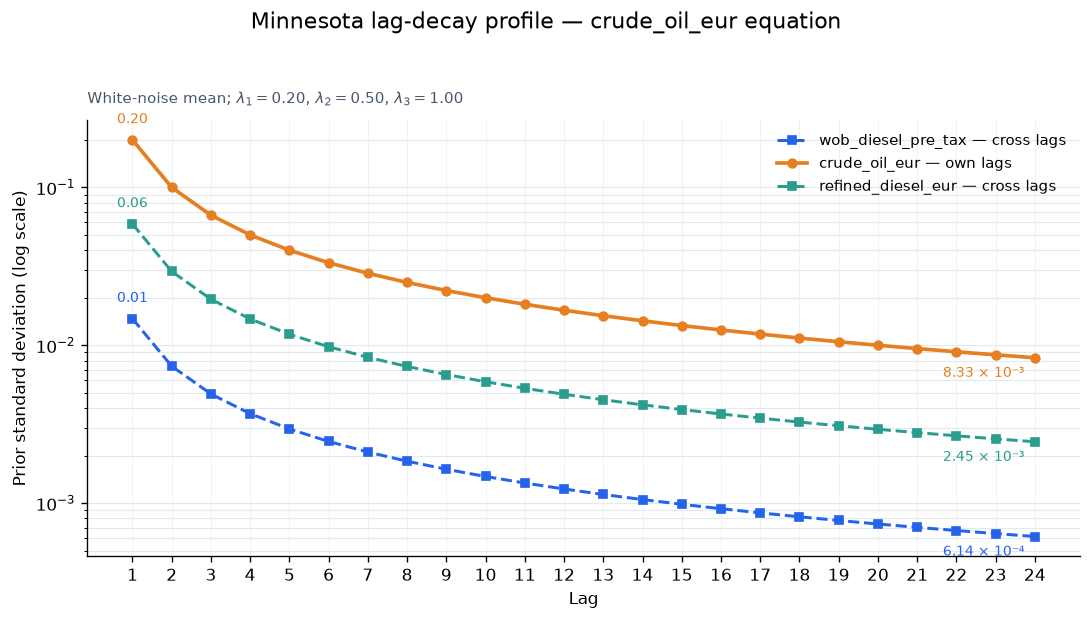

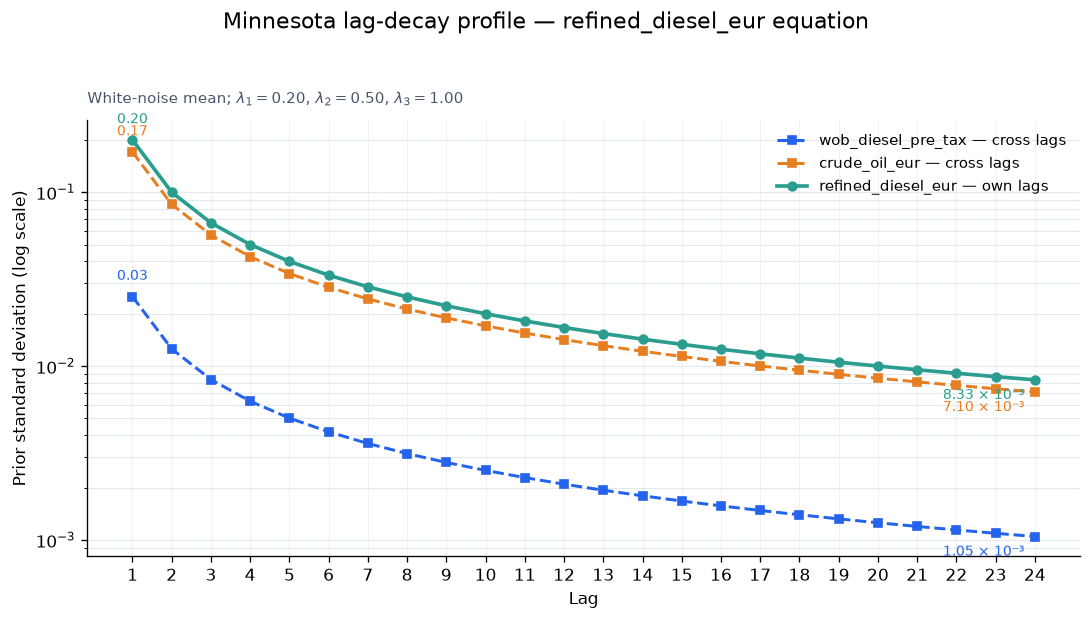

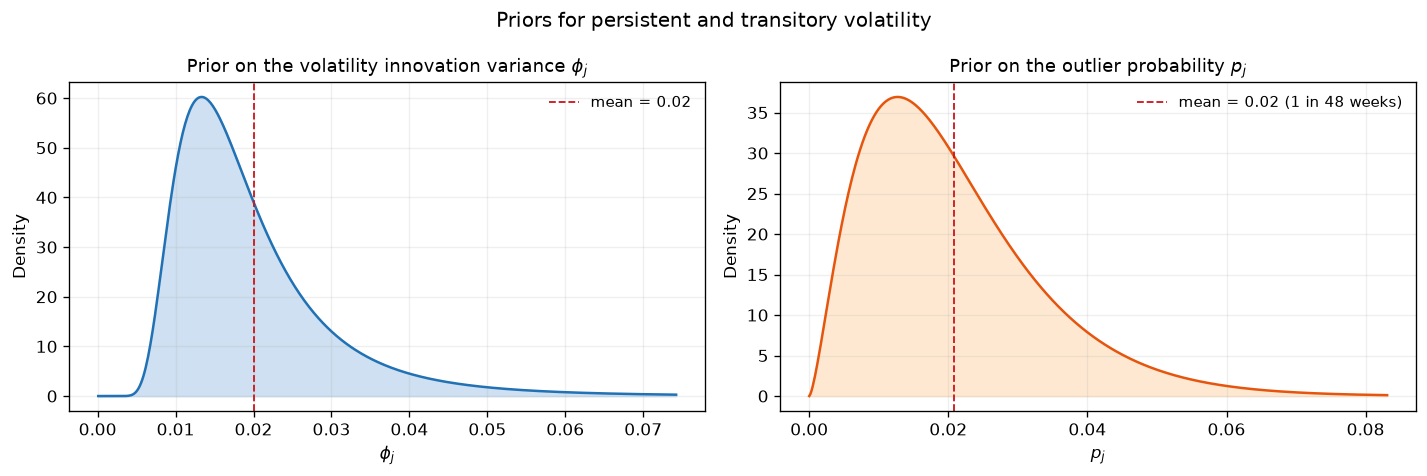

In [4]:
prior_config = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
prior = make_bvar_svo_prior(prep, prior_config)

prior_table = pd.DataFrame({
    "value": [
        prior_config.lambda1,
        prior_config.lambda2,
        prior_config.lambda3,
        prior_config.lambda4,
        prior_config.a_prior_var,
        prior_config.phi_prior_mean,
        prior["outlier_alpha"],
        prior["outlier_beta"],
    ],
    "interpretation": [
        "overall Minnesota lag tightness",
        "additional cross-lag tightness",
        "lag-decay exponent",
        "constant prior scale",
        "variance of each free contemporaneous A coefficient",
        "prior mean of volatility-of-volatility variance",
        "Beta outlier pseudo-count",
        "Beta regular-observation pseudo-count",
    ],
}, index=[
    "lambda1", "lambda2", "lambda3", "lambda4",
    "A prior variance", "phi prior mean",
    "outlier alpha", "outlier beta",
])
display(style_numeric_table(prior_table, caption="Prior hyperparameters"))

prior_figures = plot_minnesota_prior_by_equation(prior, VARIABLES, P)
for equation, figure in prior_figures.items():
    display(figure)
    plt.close(figure)
plot_phi_and_outlier_priors(prior)
plt.show()

## 4. Posterior and Gibbs sampler

In [5]:
sampler_config = SamplerConfig(
    reps=40 if FAST_MODE else 6_000,
    burn=20 if FAST_MODE else 3_000,
    thin=1,
    seed=SEED,
    max_stability_tries=1_000,
    progress_every=0 if FAST_MODE else 500,
    dk_projection_mode="strict",
    dk_level_relative_gate=1e-6,
    dk_difference_relative_gate=1e-6,
)

result = run_energy_bvar(
    levels=levels,
    model_id=COMPONENT,
    vintage=COMPONENT_DATASET.parent.name,
    p=P,
    variables=VARIABLES,
    frequency="weekly",
    prior_config=prior_config,
    sampler_config=sampler_config,
    code_version="energy_bvar-weekly-dk-da-v3-production",
)

print(f"Retained posterior draws: {result['n_draws']:,}")
print(f"Run ID: {result['metadata']['run_id']}")
print(f"Frequency: {result['metadata']['frequency']}")
print(f"Data augmentation: {result['metadata'].get('data_augmentation', 'none')}")
print(
    "B instability proposal rejection rate: "
    f"{result['B_instability_rejection_rate']:.2%}"
)
display(style_numeric_table(
    pd.Series(dict(zip(VARIABLES, result["ksc_offsets"]))).to_frame("KSC offset"),
    caption="Adaptive KSC offsets",
))

dk_diag = result.get("dk_projection_diagnostics", {})
if dk_diag:
    print(
        "DK projection max relative errors: "
        f"level={dk_diag.get('level_error', {}).get('max', np.nan):.3e}, "
        f"difference={dk_diag.get('difference_adjustment', {}).get('max', np.nan):.3e}"
    )

if SAVE_RESULTS:
    saved_result_paths = save_energy_bvar_result(result, RESULTS_ROOT)
    print(f"Saved run: {saved_result_paths['directory']}")

iteration 500/6,000 | B instability rejection 0.00% | radius 0.8814 | DK-DA missing cells 48
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8908 | DK-DA missing cells 48
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.8873 | DK-DA missing cells 48
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.8835 | DK-DA missing cells 48
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.8703 | DK-DA missing cells 48
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.8713 | DK-DA missing cells 48
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.8803 | DK-DA missing cells 48
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8970 | DK-DA missing cells 48
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.8772 | DK-DA missing cells 48
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.8816 | DK-DA missing cells 48
iteration 5,500/6,000 | B instability rejection 0.00

,KSC offset
wob_diesel_pre_tax,4.02 × 10⁻⁵
crude_oil_eur,1.62 × 10⁻⁶
refined_diesel_eur,2.77 × 10⁻⁶


DK projection max relative errors: level=3.775e-10, difference=1.790e-08


## 5. Posterior results


wob_diesel_pre_tax equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,165.04,0.24,0.24,0.24,-0.15,2.04 × 10⁻³,0.48,0.64,1497.28
wob_diesel_pre_tax L1,0.00,0.20,0.06,0.06,0.04,-0.01,0.02,0.10,0.14,1882.26
crude_oil_eur L1,0.00,0.68,0.92,0.92,0.21,0.57,0.70,1.14,1.28,1368.37
refined_diesel_eur L1,0.00,0.40,1.35,1.35,0.19,1.03,1.16,1.55,1.67,2008.88
wob_diesel_pre_tax L2,0.00,0.10,0.02,0.02,0.03,-0.04,-0.02,0.05,0.07,1690.30
crude_oil_eur L2,0.00,0.34,-0.24,-0.25,0.16,-0.50,-0.40,-0.08,0.02,1690.10
refined_diesel_eur L2,0.00,0.20,0.47,0.47,0.14,0.24,0.33,0.60,0.69,1921.36
wob_diesel_pre_tax L3,0.00,0.07,-6.76 × 10⁻³,-6.94 × 10⁻³,0.03,-0.05,-0.04,0.02,0.04,2149.10
crude_oil_eur L3,0.00,0.23,0.12,0.12,0.13,-0.10,-0.01,0.25,0.33,2292.27


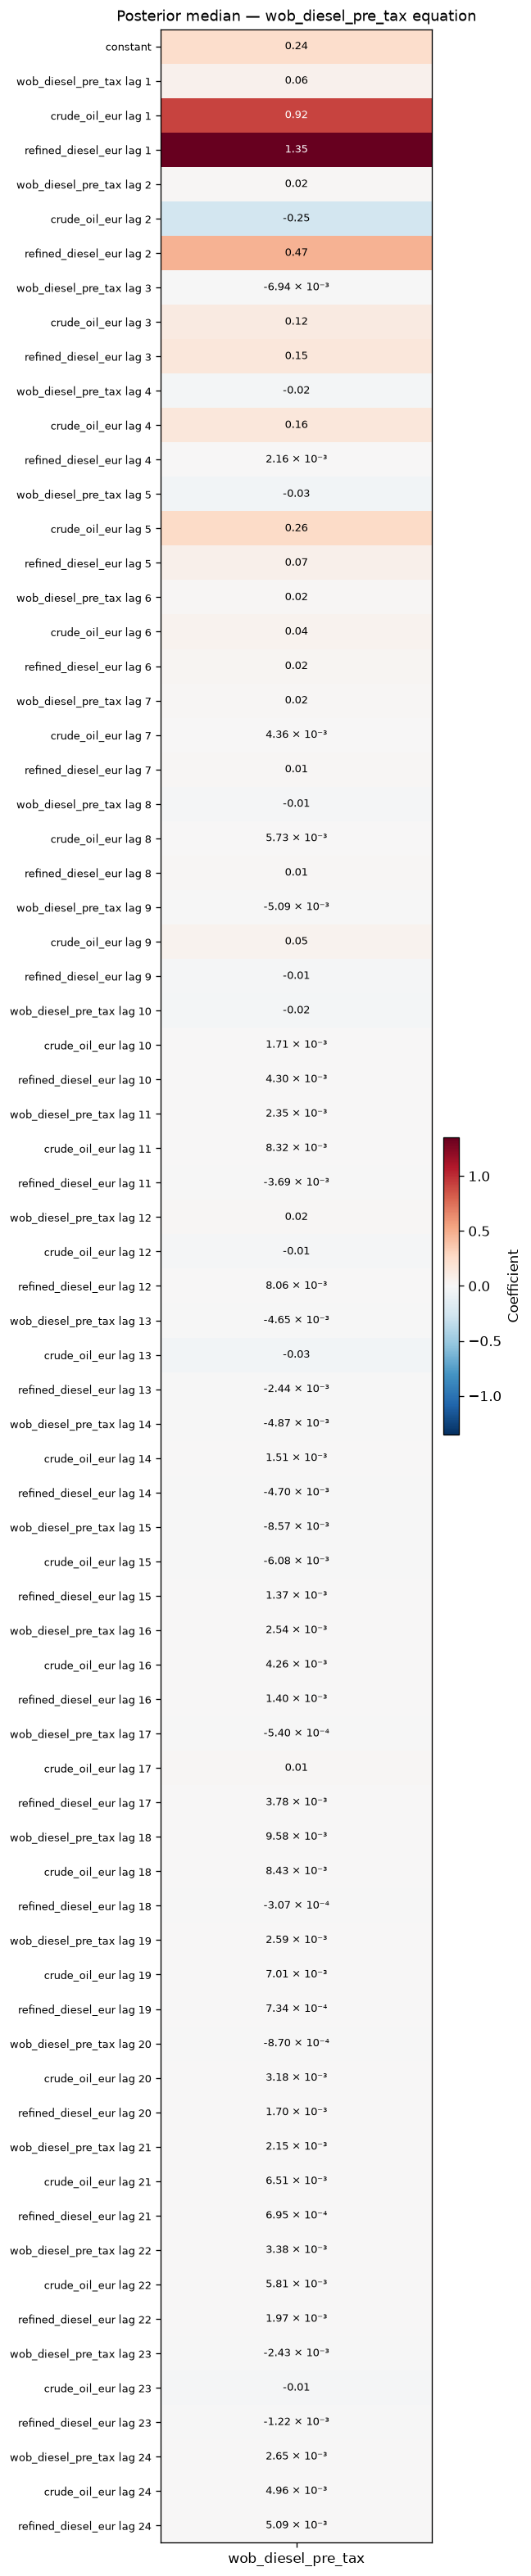

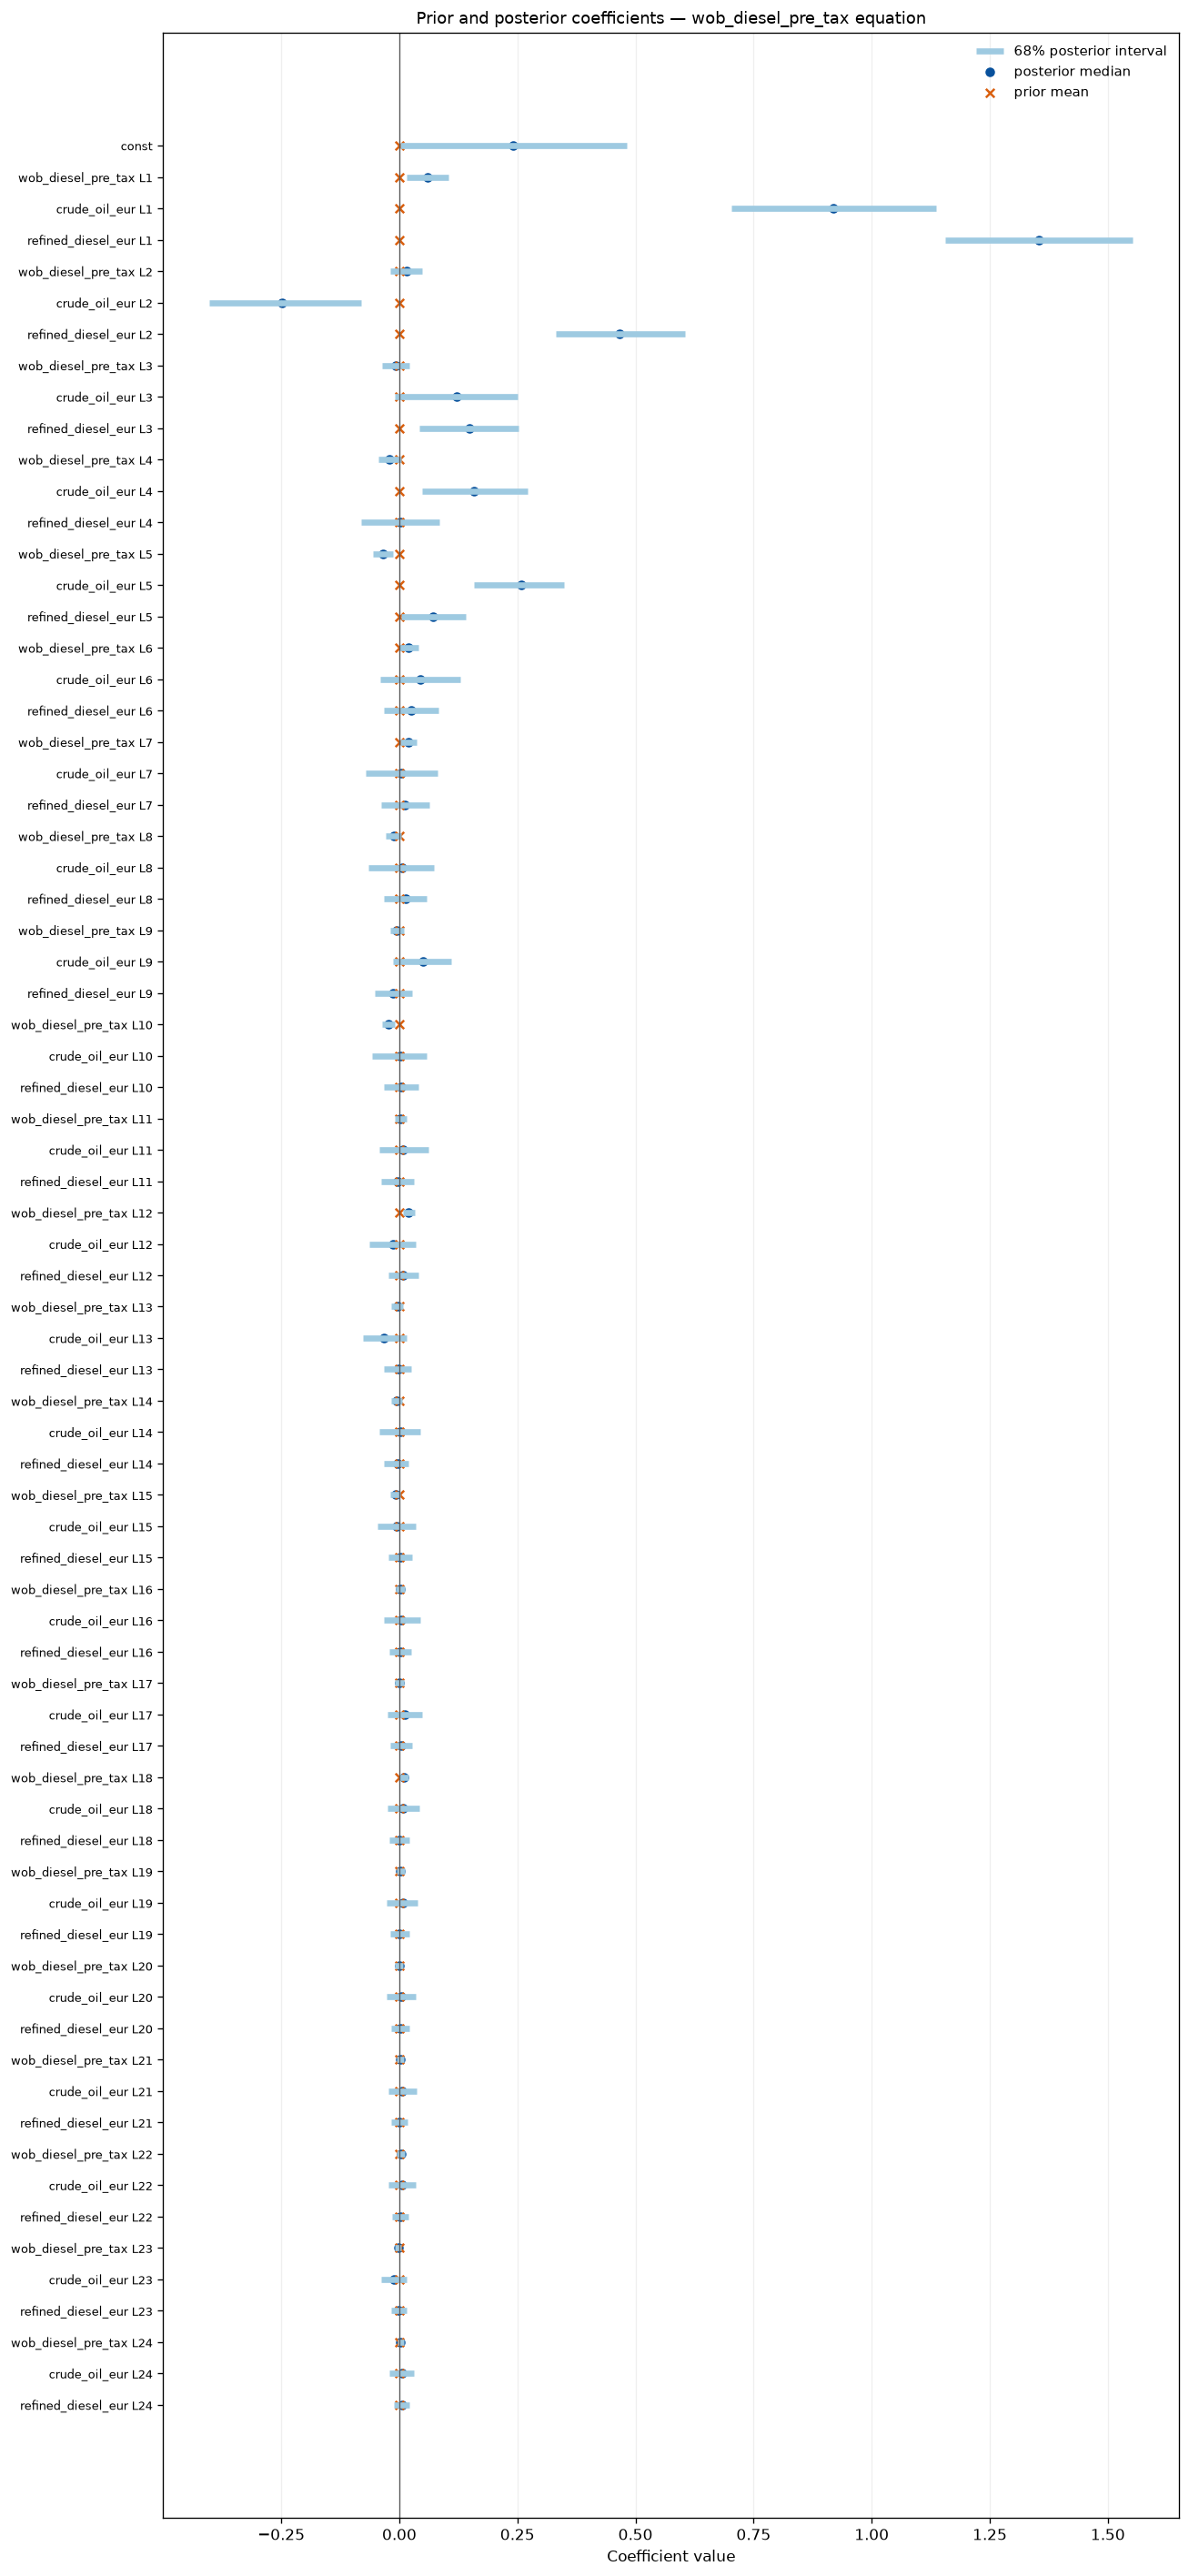


crude_oil_eur equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,24.33,0.05,0.05,0.05,-0.04,-5.11 × 10⁻³,0.10,0.13,1746.98
wob_diesel_pre_tax L1,0.00,0.01,0.02,0.02,8.20 × 10⁻³,9.22 × 10⁻³,0.01,0.03,0.04,1888.73
crude_oil_eur L1,0.00,0.20,0.20,0.20,0.05,0.12,0.15,0.24,0.27,1347.28
refined_diesel_eur L1,0.00,0.06,-0.06,-0.06,0.04,-0.12,-0.10,-0.02,2.05 × 10⁻³,2108.74
wob_diesel_pre_tax L2,0.00,7.37 × 10⁻³,-2.83 × 10⁻³,-2.94 × 10⁻³,5.27 × 10⁻³,-0.01,-8.07 × 10⁻³,2.39 × 10⁻³,5.82 × 10⁻³,2444.33
crude_oil_eur L2,0.00,0.10,-0.02,-0.02,0.03,-0.07,-0.05,0.02,0.04,2220.47
refined_diesel_eur L2,0.00,0.03,-0.02,-0.02,0.02,-0.06,-0.04,3.04 × 10⁻³,0.02,2395.07
wob_diesel_pre_tax L3,0.00,4.91 × 10⁻³,-6.52 × 10⁻⁴,-6.06 × 10⁻⁴,3.90 × 10⁻³,-7.04 × 10⁻³,-4.60 × 10⁻³,3.22 × 10⁻³,5.70 × 10⁻³,2130.82
crude_oil_eur L3,0.00,0.07,-0.02,-0.02,0.03,-0.07,-0.05,5.87 × 10⁻³,0.02,2548.69


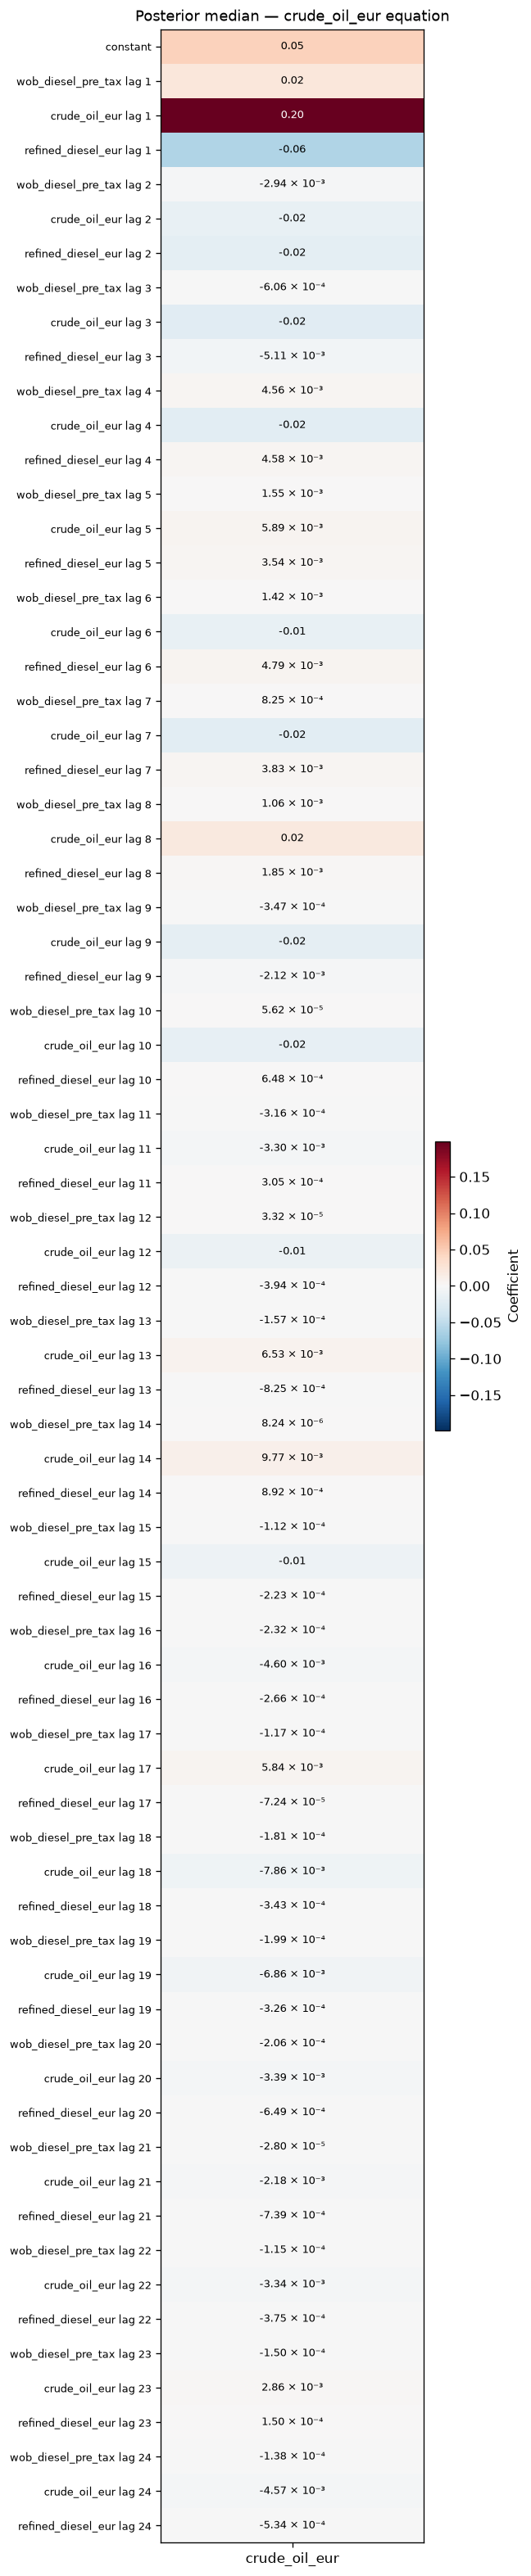

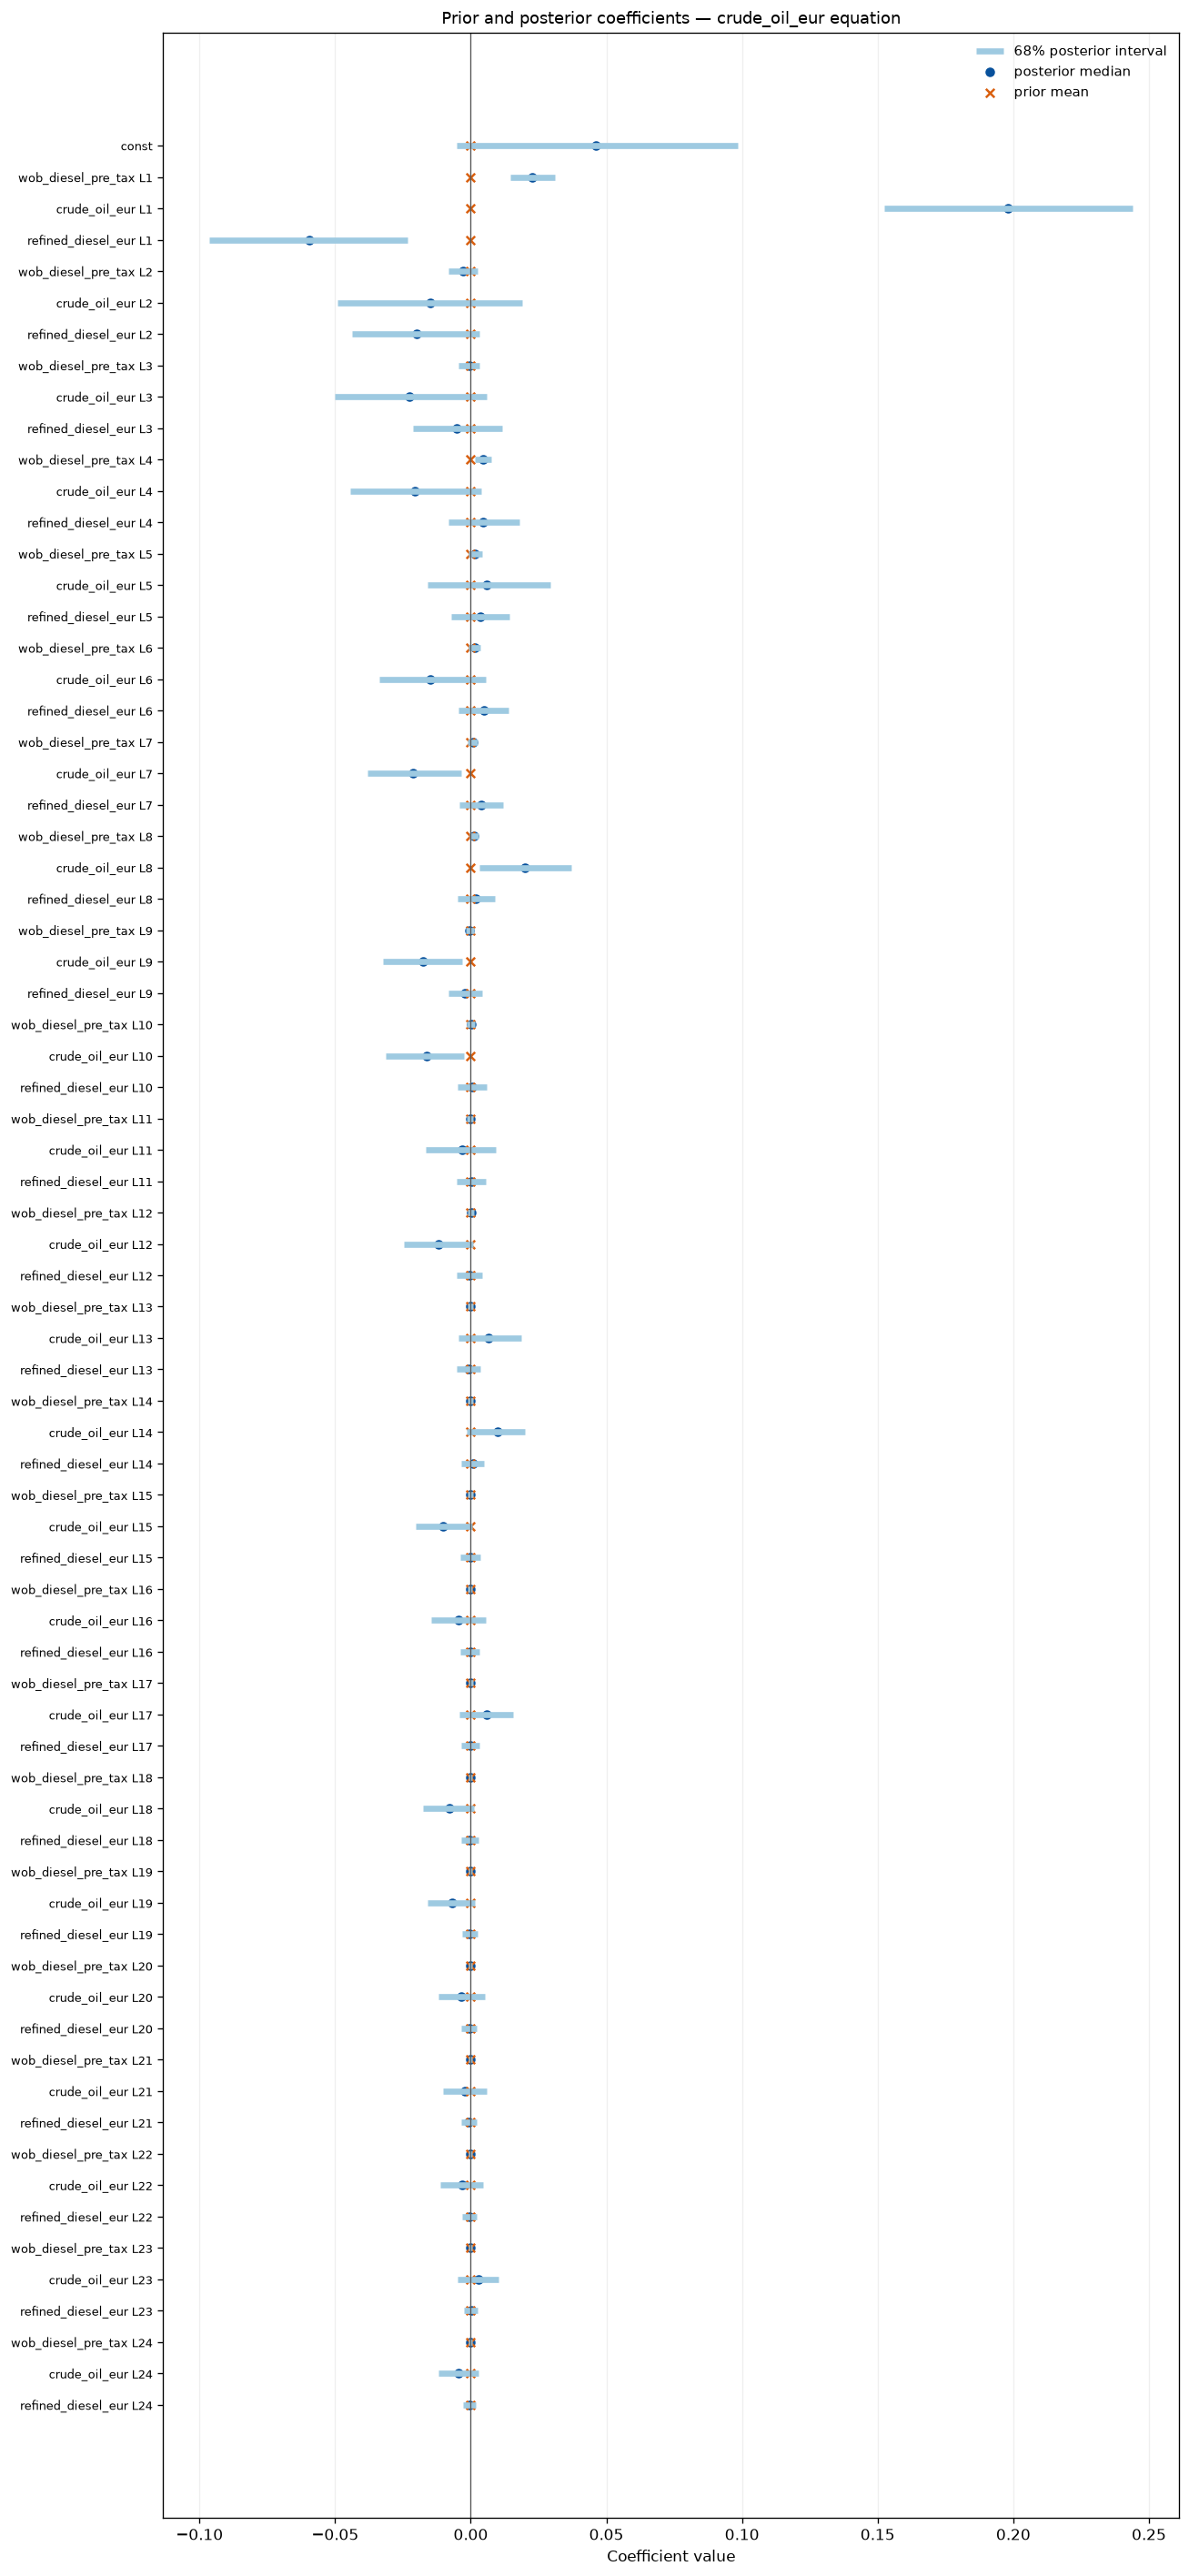


refined_diesel_eur equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,41.44,0.05,0.05,0.06,-0.05,-0.01,0.11,0.14,1642.22
wob_diesel_pre_tax L1,0.00,0.03,0.05,0.05,0.01,0.03,0.04,0.06,0.07,2084.07
crude_oil_eur L1,0.00,0.17,0.23,0.23,0.05,0.14,0.18,0.29,0.32,1357.43
refined_diesel_eur L1,0.00,0.20,-0.12,-0.12,0.05,-0.20,-0.17,-0.07,-0.04,1891.00
wob_diesel_pre_tax L2,0.00,0.01,0.01,0.01,7.33 × 10⁻³,-3.58 × 10⁻⁴,4.66 × 10⁻³,0.02,0.02,1683.59
crude_oil_eur L2,0.00,0.09,-0.04,-0.04,0.04,-0.11,-0.08,-3.12 × 10⁻³,0.02,1436.28
refined_diesel_eur L2,0.00,0.10,-0.11,-0.11,0.04,-0.17,-0.15,-0.07,-0.05,2329.32
wob_diesel_pre_tax L3,0.00,8.37 × 10⁻³,3.00 × 10⁻³,3.04 × 10⁻³,5.59 × 10⁻³,-6.33 × 10⁻³,-2.48 × 10⁻³,8.58 × 10⁻³,0.01,2615.34
crude_oil_eur L3,0.00,0.06,0.03,0.03,0.03,-0.02,3.99 × 10⁻⁴,0.07,0.09,2499.29


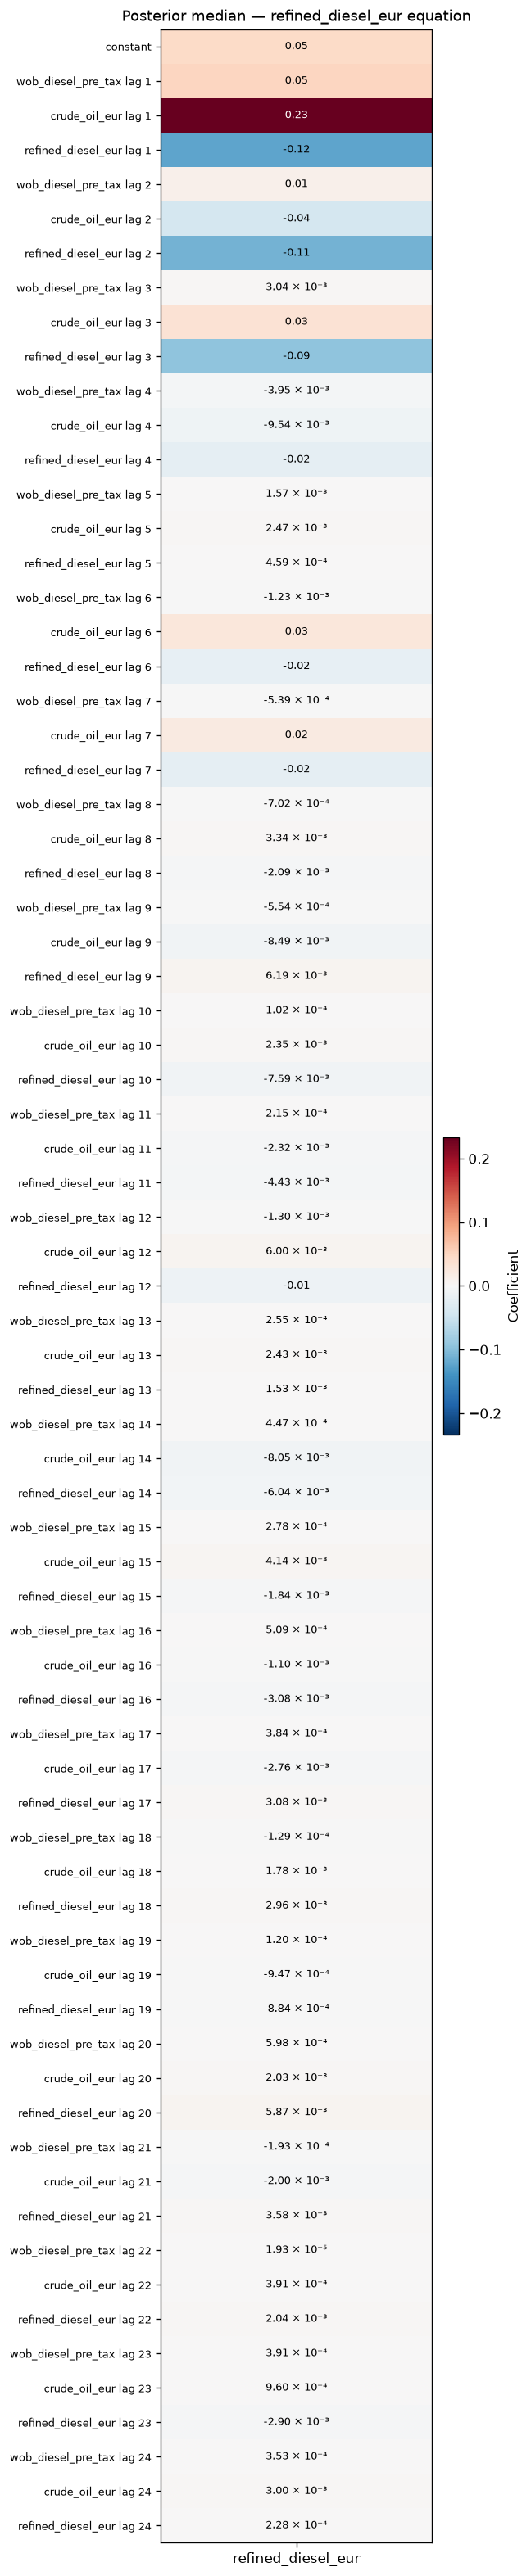

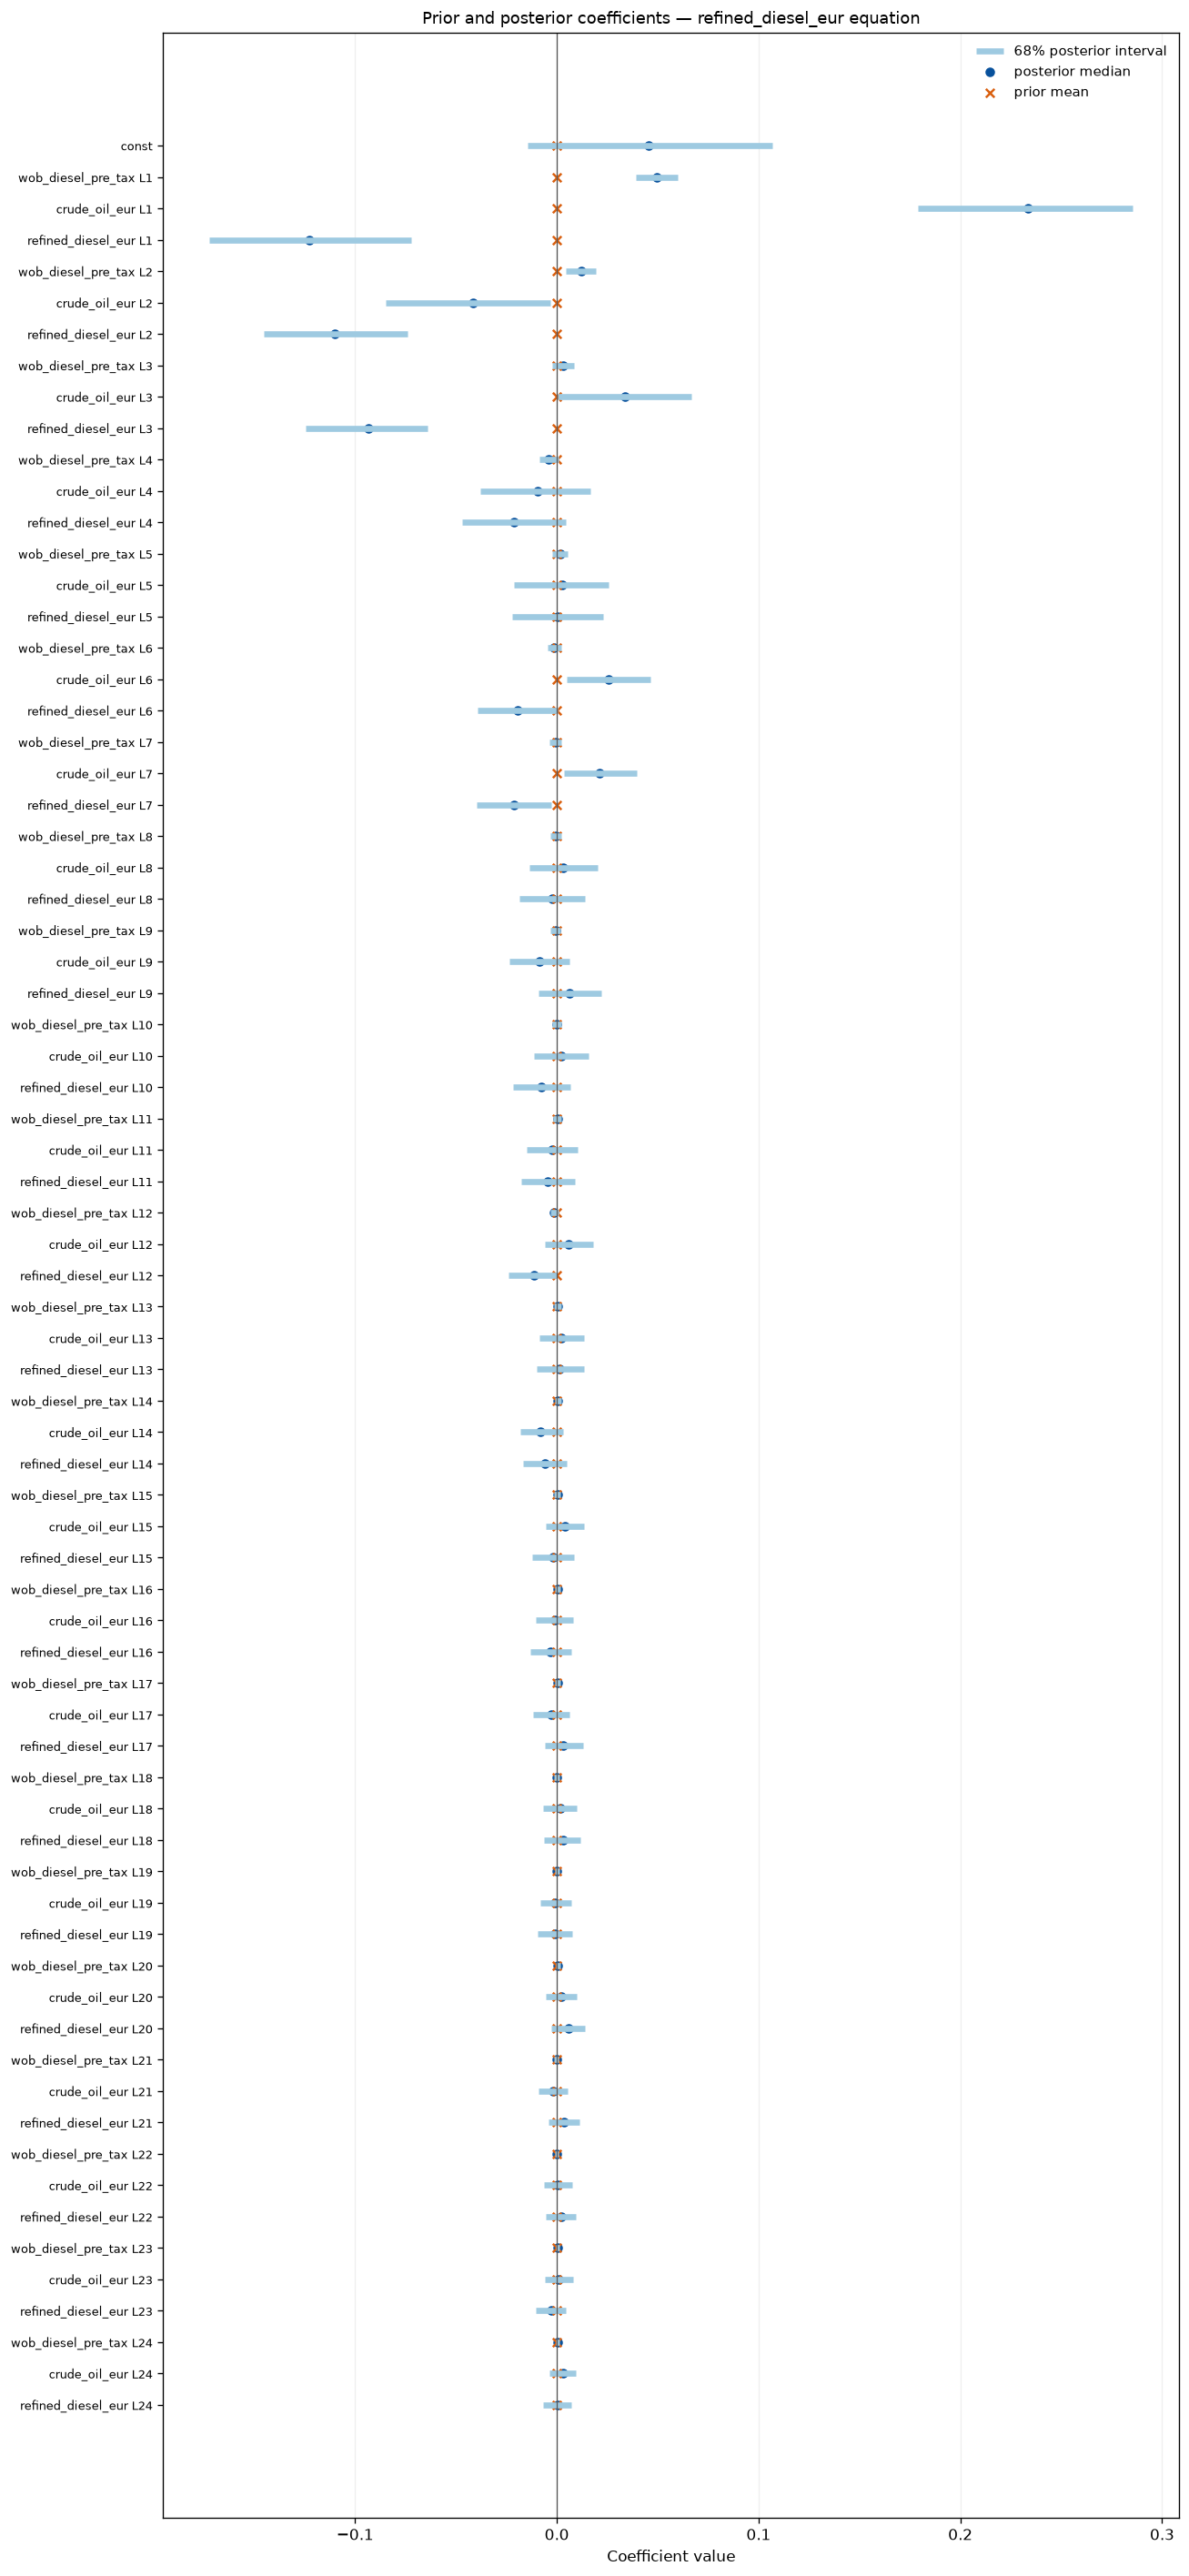

In [6]:
coefficient_tables = coefficient_posterior_tables(result)
for equation in VARIABLES:
    print()
    print(f"{equation} equation")
    display(style_numeric_table(
        coefficient_tables[equation],
        caption=f"Posterior coefficients — {equation} equation",
    ))
    plot_coefficient_heatmap(result, equation=equation)
    plot_shrinkage_comparison(result, equations=[equation])
    plt.show()

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
log likelihood,-7136.68,19.51,256.76,1.22,0.06
spectral radius,0.88,8.59 × 10⁻³,3000.00,1.57 × 10⁻⁴,0.02
"A[crude_oil_eur,wob_diesel_pre_tax]",-0.17,4.66 × 10⁻³,842.70,1.61 × 10⁻⁴,0.03
phi[wob_diesel_pre_tax],0.04,8.81 × 10⁻³,38.58,1.42 × 10⁻³,0.16
p_outlier[wob_diesel_pre_tax],5.88 × 10⁻³,3.58 × 10⁻³,42.60,5.49 × 10⁻⁴,0.15
own L1[wob_diesel_pre_tax],0.06,0.04,1882.26,1.02 × 10⁻³,0.02
phi[crude_oil_eur],0.03,8.12 × 10⁻³,41.39,1.26 × 10⁻³,0.16
p_outlier[crude_oil_eur],6.67 × 10⁻³,3.00 × 10⁻³,805.74,1.06 × 10⁻⁴,0.04
own L1[crude_oil_eur],0.20,0.05,1347.28,1.25 × 10⁻³,0.03
phi[refined_diesel_eur],0.04,9.45 × 10⁻³,60.32,1.22 × 10⁻³,0.13


,value
retained_draws,3000.00
median_spectral_radius,0.88
q95_spectral_radius,0.89
maximum_spectral_radius,0.91
retained_unstable_share,0.00
B_total_proposals,6000.00
B_unstable_proposals,0.00
B_instability_rejection_rate,0.00


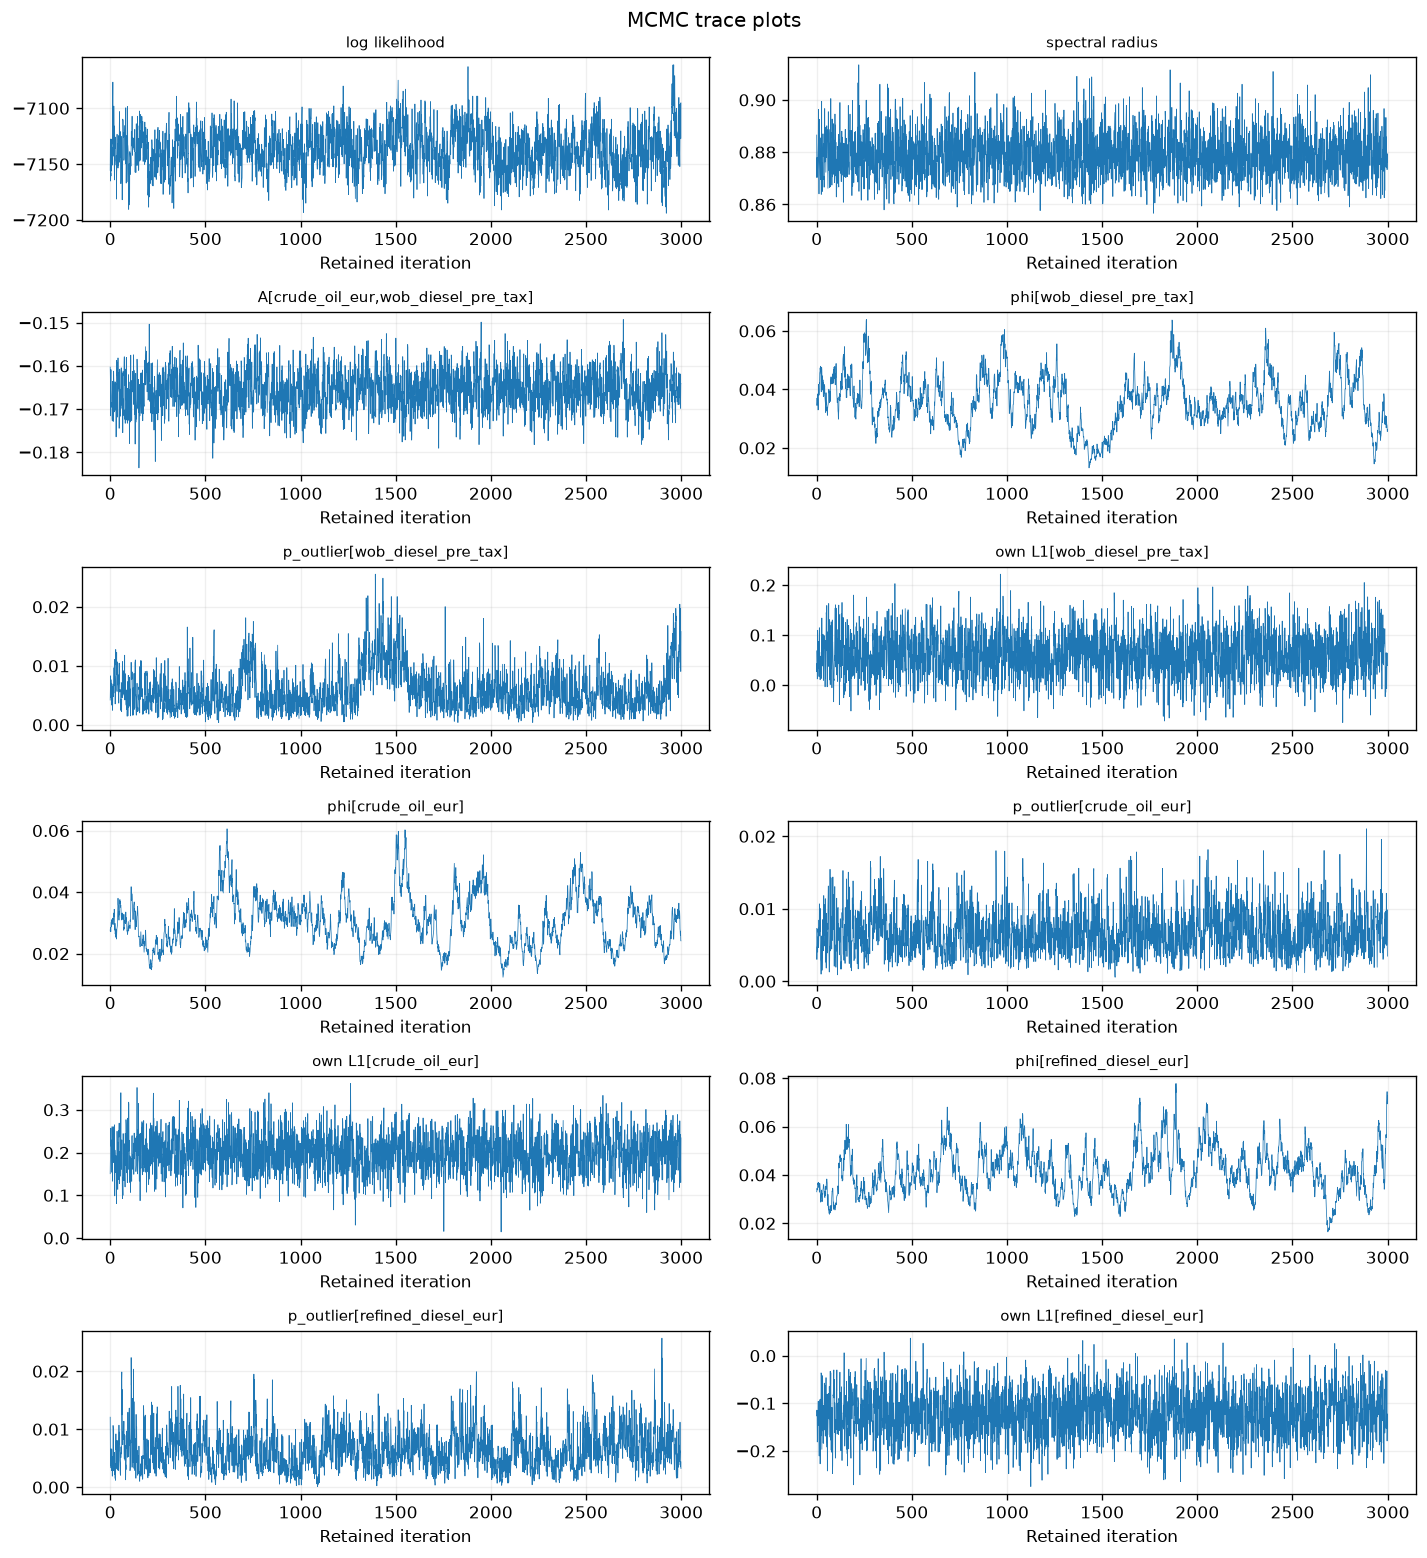

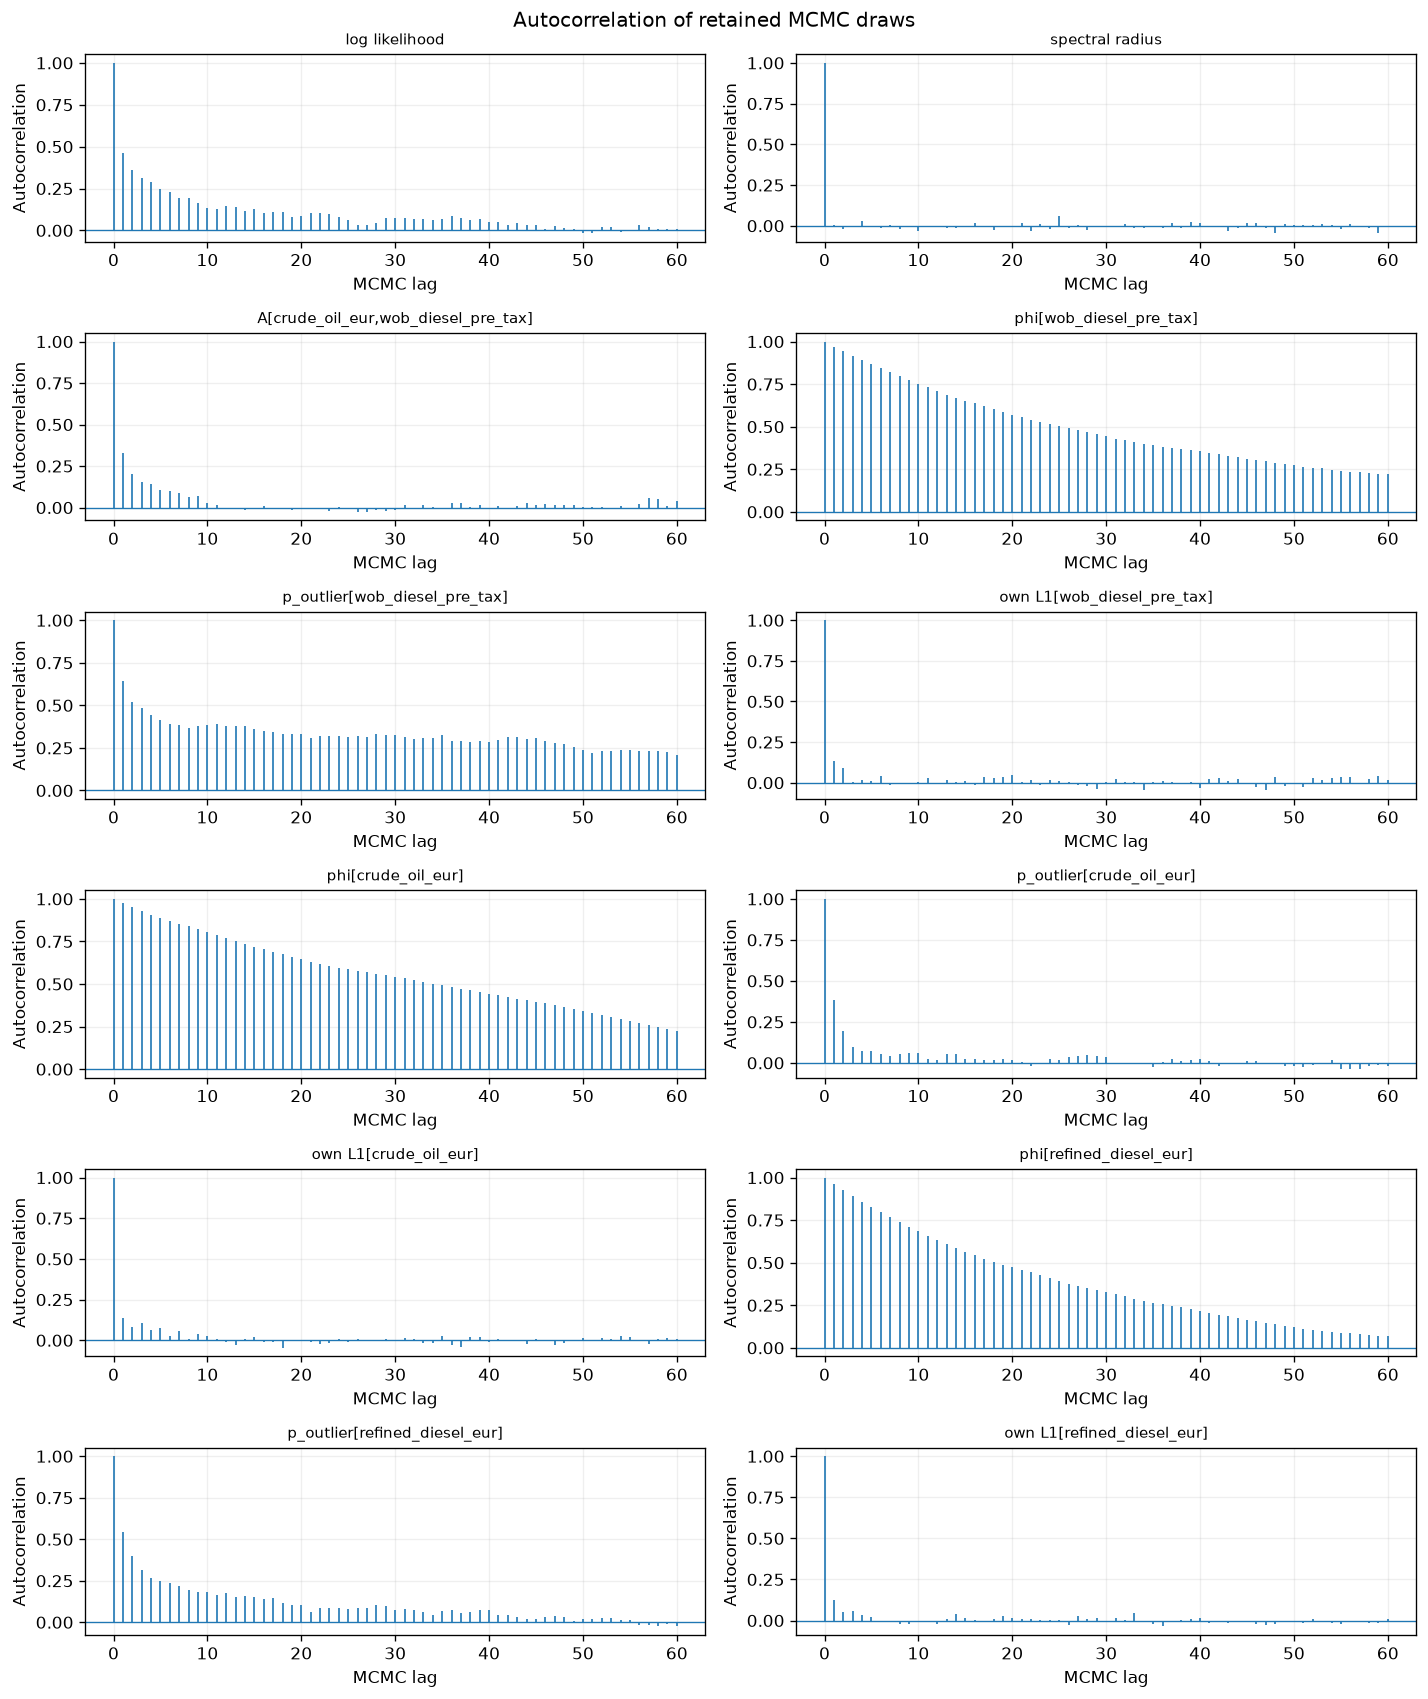

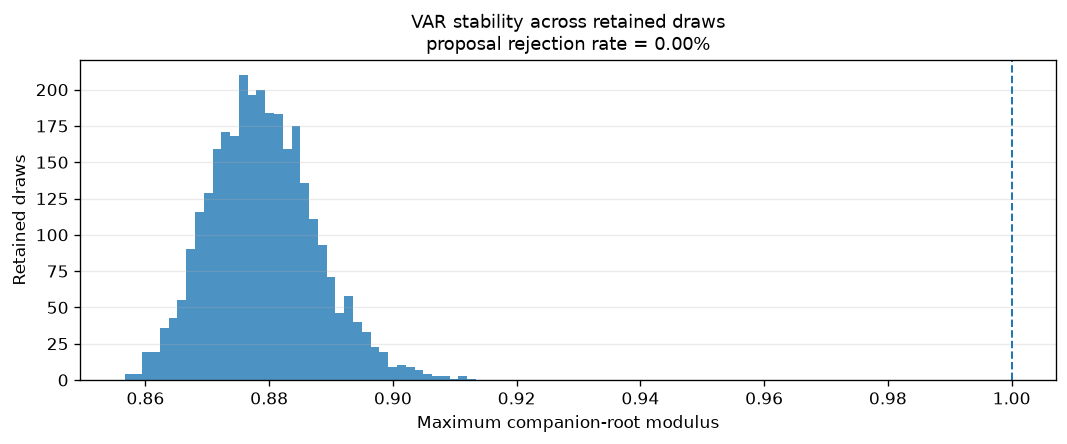

In [7]:
display(style_numeric_table(
    mcmc_diagnostics(result),
    caption="MCMC diagnostics",
))
display(style_numeric_table(
    stability_diagnostics(result).to_frame("value"),
    caption="VAR stability diagnostics",
))
plot_trace_grid(result)
plt.show()
plot_chain_acf_grid(result, nlags=60)
plt.show()
plot_spectral_radius(result)
plt.show()

,wob_diesel_pre_tax,crude_oil_eur,refined_diesel_eur
date,,,
2026-03-09,0.98,0.93,7.67 × 10⁻³
2020-03-16,0.35,0.57,3.00 × 10⁻³
2022-03-21,0.20,0.12,0.86
2022-03-14,0.19,0.98,0.67
2022-03-07,0.15,2.00 × 10⁻³,6.67 × 10⁻⁴
2019-06-10,0.13,2.67 × 10⁻³,7.67 × 10⁻³
2022-03-28,0.11,1.67 × 10⁻³,0.27
2022-04-04,0.11,3.33 × 10⁻³,2.33 × 10⁻³
2015-02-09,0.09,3.67 × 10⁻³,2.00 × 10⁻³


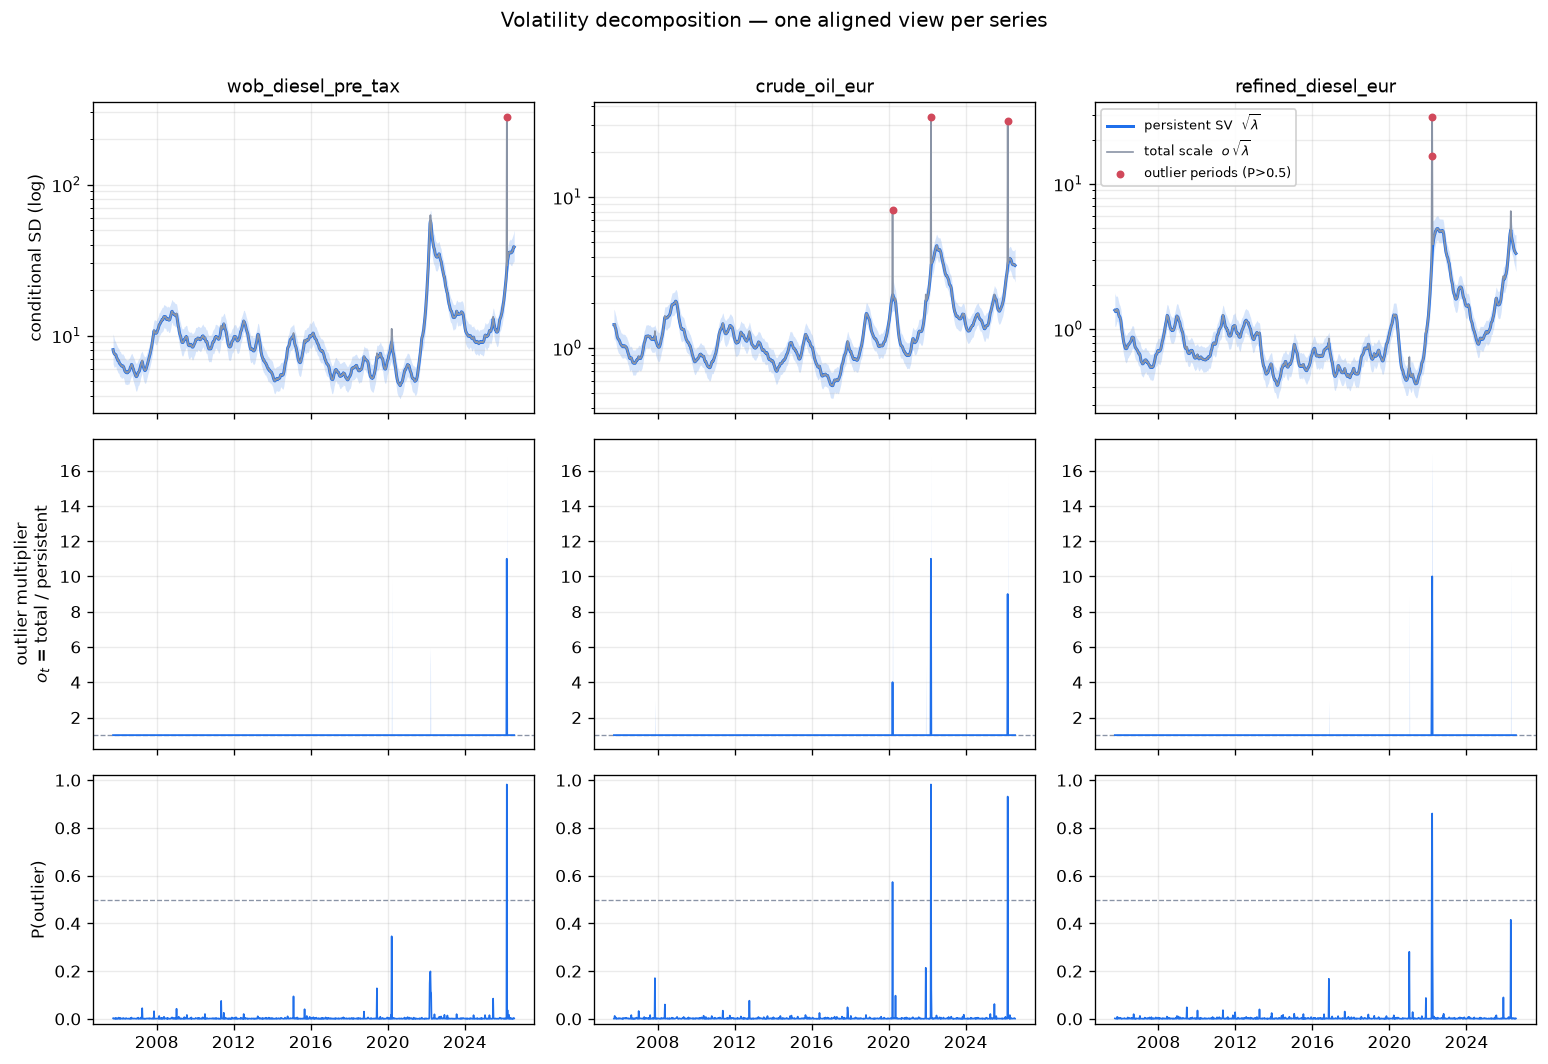

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
wob_diesel_pre_tax,-4.00 × 10⁻³,0.97,0.06,-0.10,0.03,3.38
crude_oil_eur,-7.51 × 10⁻³,0.96,-0.13,-0.21,-4.99 × 10⁻³,3.05
refined_diesel_eur,-3.46 × 10⁻³,0.96,-0.13,-0.07,-0.01,3.53


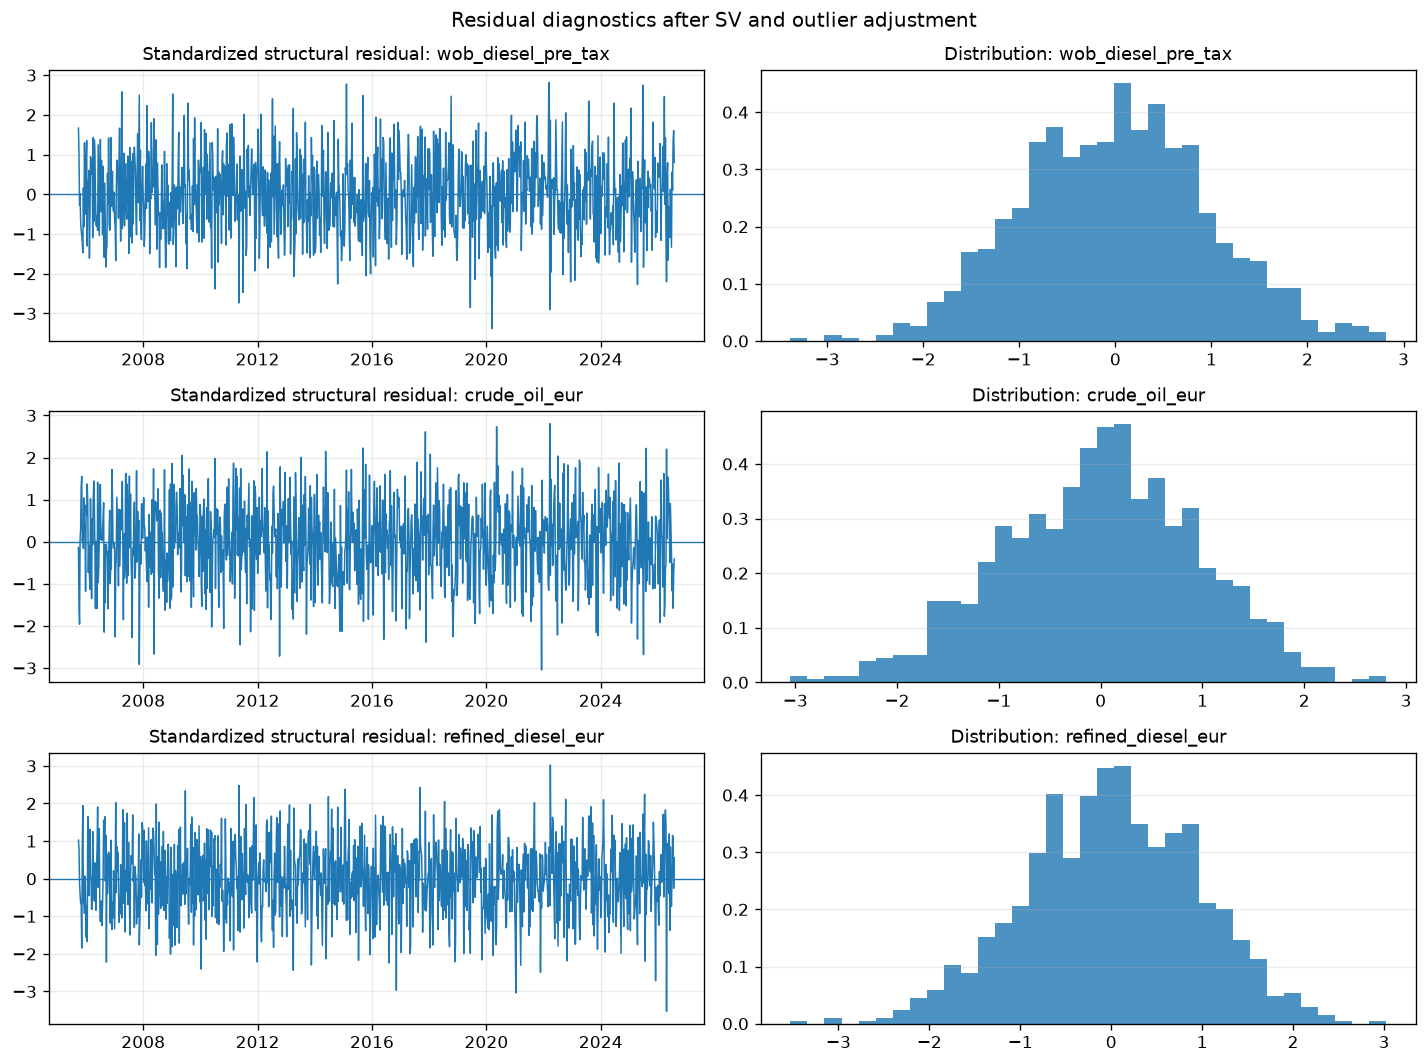

In [8]:
outlier_probability = posterior_outlier_probability(result)
display(style_numeric_table(
    outlier_probability.sort_values(TARGET, ascending=False).head(15),
    caption="Largest posterior outlier probabilities",
))
plot_volatility_decomposition(result)
plt.show()

display(style_numeric_table(
    residual_diagnostic_table(result),
    caption="Standardized structural-residual diagnostics",
))
plot_standardized_residuals(result)
plt.show()

,observed,replicated_median,replicated_q05,replicated_q95
wob_diesel_pre_tax: mean,0.60,0.41,-1.64,2.27
wob_diesel_pre_tax: sd,17.93,19.04,15.27,33.98
wob_diesel_pre_tax: maximum_absolute,215.90,238.75,121.15,720.91
crude_oil_eur: mean,0.03,0.05,-0.23,0.32
crude_oil_eur: sd,2.48,3.71,2.90,6.03
crude_oil_eur: maximum_absolute,17.23,60.53,24.57,140.21
refined_diesel_eur: mean,0.07,0.06,-0.28,0.34
refined_diesel_eur: sd,4.17,4.58,3.62,7.20
refined_diesel_eur: maximum_absolute,48.32,71.66,28.26,168.27


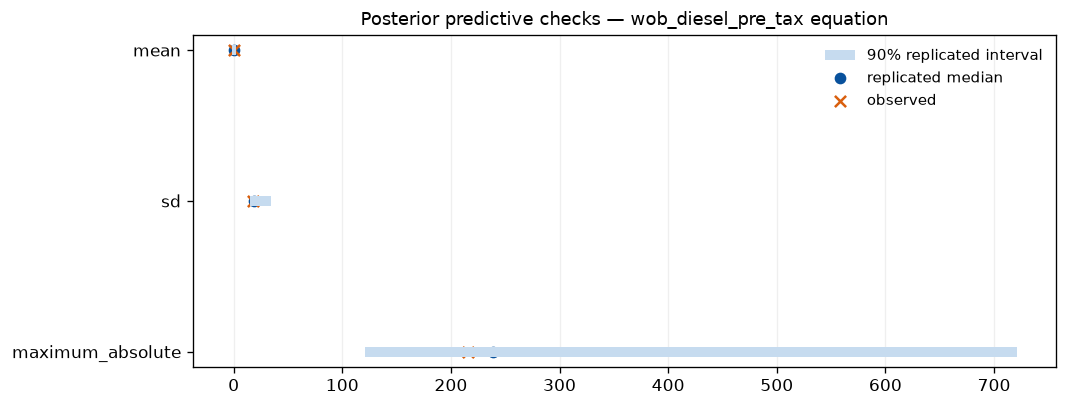

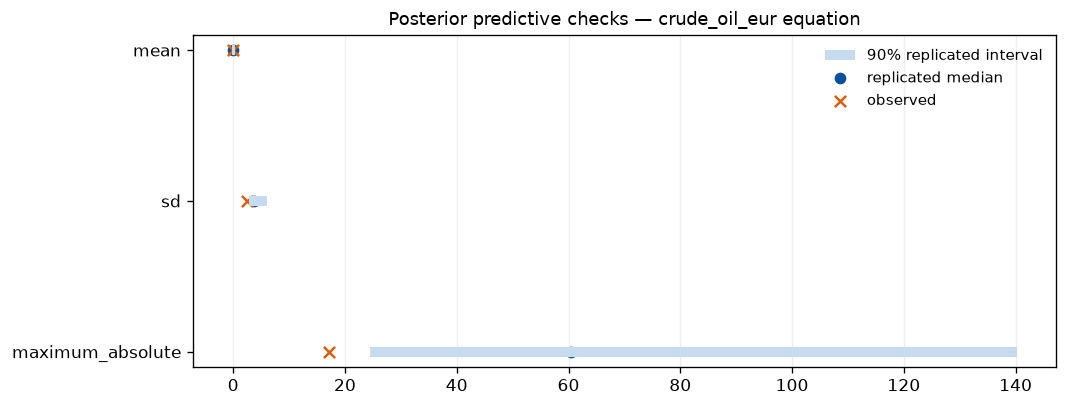

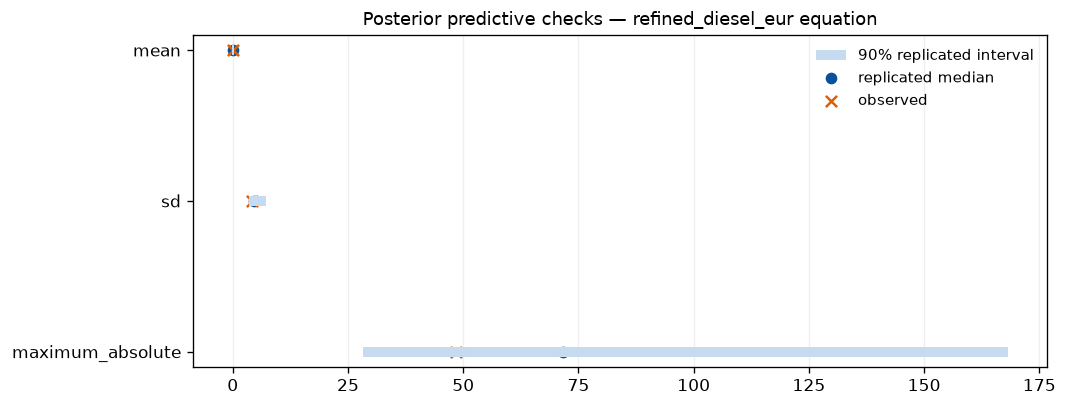

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
wob_diesel_pre_tax,-6.78,2.57 × 10⁻⁹,17.00,0.08,0.10,9.00,1094.00
crude_oil_eur,-8.27,4.84 × 10⁻¹³,16.00,0.04,0.10,6.00,1095.00
refined_diesel_eur,-7.46,5.43 × 10⁻¹¹,17.00,0.07,0.10,2.00,1094.00


,,q05,q16,median,q84,q95,posterior_sd
date,variable,,,,,,
2005-10-31,wob_diesel_pre_tax,520.12,522.84,526.36,529.85,532.30,3.68
2005-12-26,wob_diesel_pre_tax,478.73,481.20,485.10,489.24,491.75,4.01
2006-01-02,wob_diesel_pre_tax,480.98,483.36,487.11,490.78,493.10,3.72
2006-04-17,wob_diesel_pre_tax,527.06,528.90,531.62,534.28,536.23,2.76
2006-12-25,wob_diesel_pre_tax,469.45,471.15,473.79,476.39,478.26,2.69
2007-01-01,wob_diesel_pre_tax,465.51,467.56,470.53,473.48,475.16,2.95
2007-04-09,wob_diesel_pre_tax,485.99,487.70,490.33,493.14,494.96,2.73
2007-12-24,wob_diesel_pre_tax,607.15,609.75,613.17,616.54,618.87,3.53
2007-12-31,wob_diesel_pre_tax,612.97,615.14,618.53,622.01,624.46,3.53


In [9]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=PPC_DRAWS,
    seed=456,
)
display(style_numeric_table(
    ppc_summary,
    caption="Posterior predictive checks",
))
for equation in VARIABLES:
    plot_posterior_predictive_check(ppc_summary, equation=equation)
    plt.show()

completed_changes = posterior_completed_differences(result, statistic="median")
display(style_numeric_table(
    stationarity_tests(completed_changes),
    caption="Stationarity tests on posterior-median completed weekly changes",
))

if "missing_level_draws" in result and result["missing_level_draws"].shape[1]:
    q = np.percentile(result["missing_level_draws"], [5, 16, 50, 84, 95], axis=0)
    positions = result["missing_level_positions"]
    imputed_summary = pd.DataFrame({
        "date": [item[0] for item in positions],
        "variable": [item[1] for item in positions],
        "q05": q[0],
        "q16": q[1],
        "median": q[2],
        "q84": q[3],
        "q95": q[4],
        "posterior_sd": np.std(result["missing_level_draws"], axis=0, ddof=1),
    }).set_index(["date", "variable"])
    display(style_numeric_table(
        imputed_summary,
        caption="Posterior draws for internally missing weekly levels",
    ))


## 6. Ragged-edge nowcast and weekly forecast

,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-08-03,nowcast,—,1167.23,1180.28,1200.93,1218.83,1232.52
2026-08-10,nowcast,—,1137.23,1170.32,1214.14,1257.75,1285.99


,weeks_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 week,1.00,2026-08-17,1082.60,1140.43,1215.03,1295.19,1340.56
4 weeks,4.00,2026-09-07,956.31,1079.87,1218.76,1375.07,1483.73
13 weeks,13.00,2026-11-09,678.98,899.08,1204.02,1497.85,1731.76
26 weeks,26.00,2027-02-08,368.35,774.52,1227.45,1612.46,1922.99


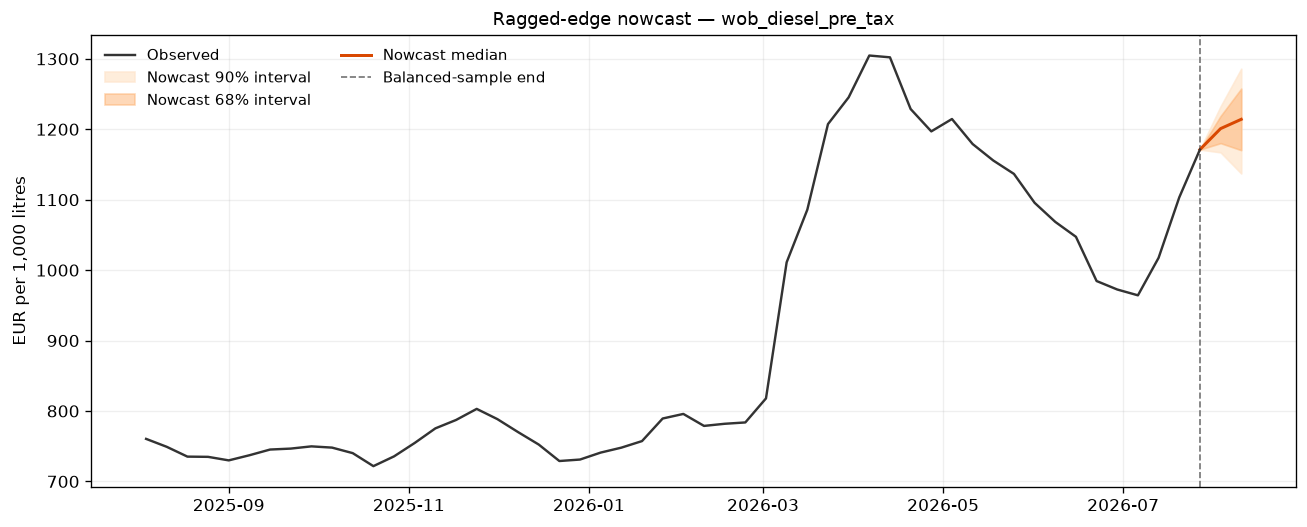

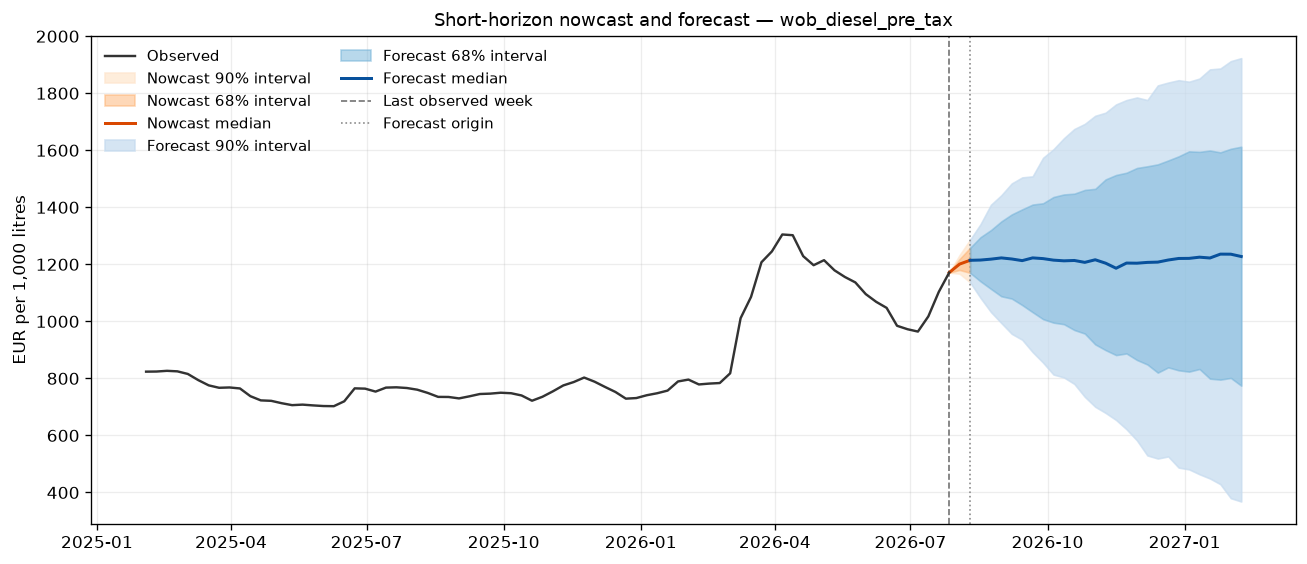

In [10]:
forecast_unconditional = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    n_draws=FORECAST_DRAWS,
    seed=123,
)

display(style_numeric_table(
    nowcast_summary_table(
        forecast_unconditional,
        observed_levels=levels,
        variable=TARGET,
        missing_only=True,
    ),
    caption="Ragged-edge diesel nowcast",
))
display(style_numeric_table(
    weekly_forecast_horizon_table(
        forecast_unconditional,
        TARGET,
        horizons=(1, 4, 13, 26),
    ),
    caption="Weekly diesel pre-tax forecast",
))

plot_nowcast_fan(
    forecast_unconditional,
    levels,
    TARGET,
    last_obs=52,
    ylabel=UNITS[TARGET],
)
plt.show()
plot_short_forecast_fan(
    forecast_unconditional,
    levels,
    TARGET,
    last_obs=78,
    ylabel=UNITS[TARGET],
)
plt.show()

## 7. Conditional commodity-price scenarios

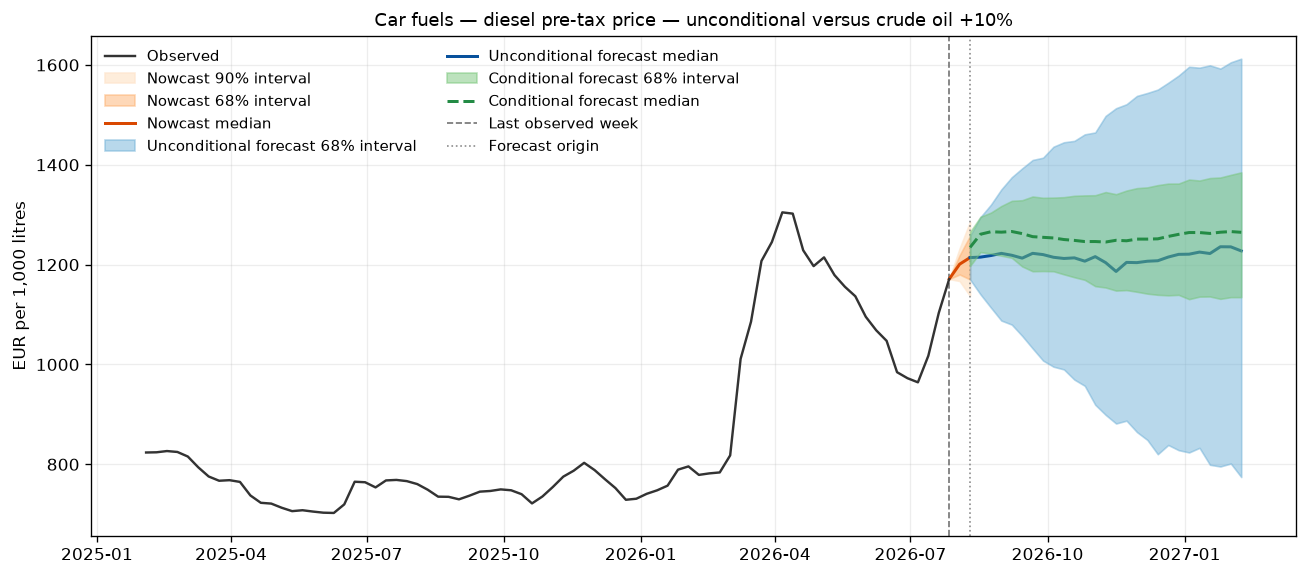

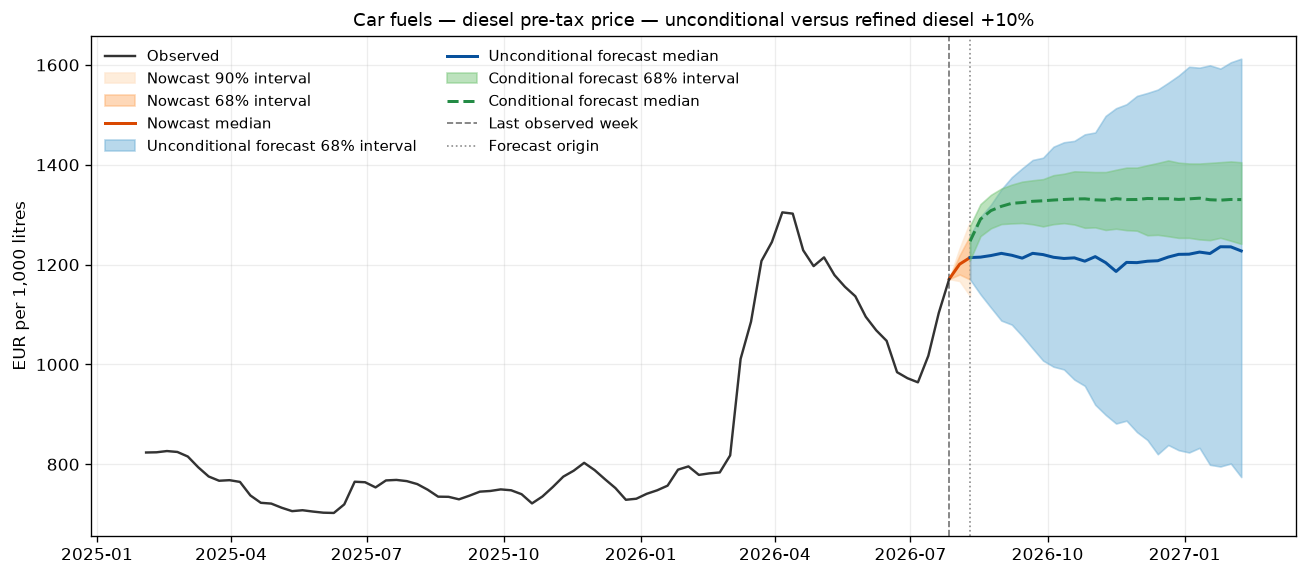

In [11]:
last_crude = float(levels["crude_oil_eur"].dropna().iloc[-1])
last_refined = float(levels["refined_diesel_eur"].dropna().iloc[-1])
crude_up_10 = np.full(FORECAST_H, 1.10 * last_crude)
refined_up_10 = np.full(FORECAST_H, 1.10 * last_refined)

forecast_crude_up_10 = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    level_conditions={"crude_oil_eur": crude_up_10},
    n_draws=FORECAST_DRAWS,
    seed=123,
)
forecast_refined_up_10 = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    level_conditions={"refined_diesel_eur": refined_up_10},
    n_draws=FORECAST_DRAWS,
    seed=123,
)

plot_forecast_comparison(
    forecast_unconditional,
    forecast_crude_up_10,
    levels,
    TARGET,
    last_obs=78,
    title="Car fuels — diesel pre-tax price — unconditional versus crude oil +10%",
    ylabel=UNITS[TARGET],
)
plt.show()
plot_forecast_comparison(
    forecast_unconditional,
    forecast_refined_up_10,
    levels,
    TARGET,
    last_obs=78,
    title="Car fuels — diesel pre-tax price — unconditional versus refined diesel +10%",
    ylabel=UNITS[TARGET],
)
plt.show()


## 8. Ex-post tax re-attribution

The BVAR forecasts the pre-tax WOB price. Excise and VAT are re-attributed after
forecasting under the paper's random-walk assumption:

$$
P_t^{\mathrm{after\ tax}}
=\left(P_t^{\mathrm{pre\ tax}}+\mathrm{excise}_t\right)
\left(1+\frac{\mathrm{VAT}_t}{100}\right).
$$

Petrol and diesel are combined only after both sub-models have been estimated.


,value
WOB source,C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\interim\european_commission\2026-08-04\wob_weekly.csv
WOB prefix,wob_diesel
maximum historical tax-identity error,0.0
forecast excise,525.229224
forecast VAT percent,20.78555
tax assumption,random walk / latest value carried forward


,q05,q16,median,q84,q95
date,,,,,
2026-08-01,1961.66,2015.55,2099.12,2182.41,2243.82
2026-09-01,1754.40,1897.43,2110.23,2323.22,2439.52
2026-10-01,1590.02,1828.66,2089.04,2378.95,2627.40
2026-11-01,1421.18,1711.09,2071.71,2460.23,2712.19
2026-12-01,1276.74,1640.26,2094.64,2523.08,2817.99
2027-01-01,1196.18,1620.63,2106.94,2551.26,2876.11
2027-02-01,1088.13,1596.83,2119.85,2575.42,2963.05


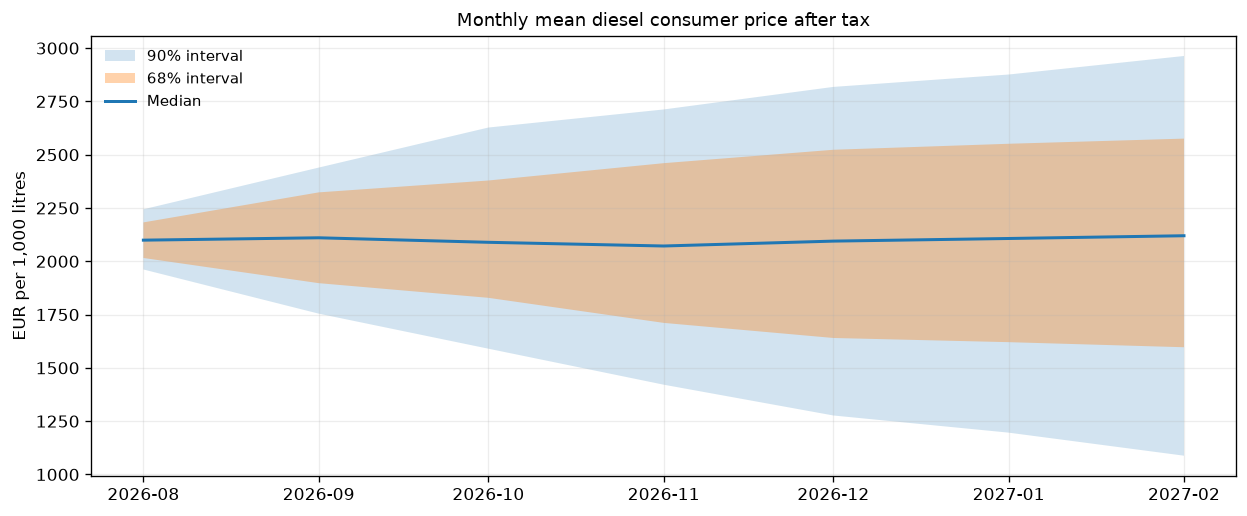

In [12]:
try:
    tax_context = load_weekly_tax_context(COMPONENT_DATASET, model=MODEL)
    taxed_forecast = reattribute_weekly_taxes(
        forecast_unconditional,
        tax_context,
    )
    monthly_after_tax_paths, monthly_after_tax_dates = weekly_paths_to_monthly_mean(
        taxed_forecast["after_tax_paths"],
        taxed_forecast["path_dates"],
    )

    tax_summary = pd.Series({
        "WOB source": str(tax_context["wob_path"]),
        "WOB prefix": tax_context["wob_prefix"],
        "maximum historical tax-identity error": tax_context["max_tax_identity_error"],
        "forecast excise": taxed_forecast["excise"][-1],
        "forecast VAT percent": taxed_forecast["vat_percent"][-1],
        "tax assumption": taxed_forecast["tax_assumption"],
    })
    display(style_numeric_table(
        tax_summary.to_frame("value"),
        caption="Tax re-attribution inputs",
    ))

    monthly_q = np.percentile(
        monthly_after_tax_paths,
        [5, 16, 50, 84, 95],
        axis=0,
    )
    monthly_after_tax_table = pd.DataFrame({
        "q05": monthly_q[0],
        "q16": monthly_q[1],
        "median": monthly_q[2],
        "q84": monthly_q[3],
        "q95": monthly_q[4],
    }, index=monthly_after_tax_dates)
    display(style_numeric_table(
        monthly_after_tax_table,
        caption="Monthly mean diesel consumer price after tax",
    ))

    fig, ax = plt.subplots(figsize=(10.5, 4.4))
    ax.fill_between(
        monthly_after_tax_dates,
        monthly_q[0],
        monthly_q[4],
        alpha=0.20,
        label="90% interval",
    )
    ax.fill_between(
        monthly_after_tax_dates,
        monthly_q[1],
        monthly_q[3],
        alpha=0.35,
        label="68% interval",
    )
    ax.plot(monthly_after_tax_dates, monthly_q[2], linewidth=1.8, label="Median")
    ax.set_title("Monthly mean diesel consumer price after tax")
    ax.set_ylabel("EUR per 1,000 litres")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
except (FileNotFoundError, KeyError, ValueError) as error:
    tax_context = None
    taxed_forecast = None
    print("Tax re-attribution was not run:")
    print(error)
    print("The BVAR forecast itself is unaffected; restore the WOB source path or pass it explicitly.")

## 9. Structural analysis

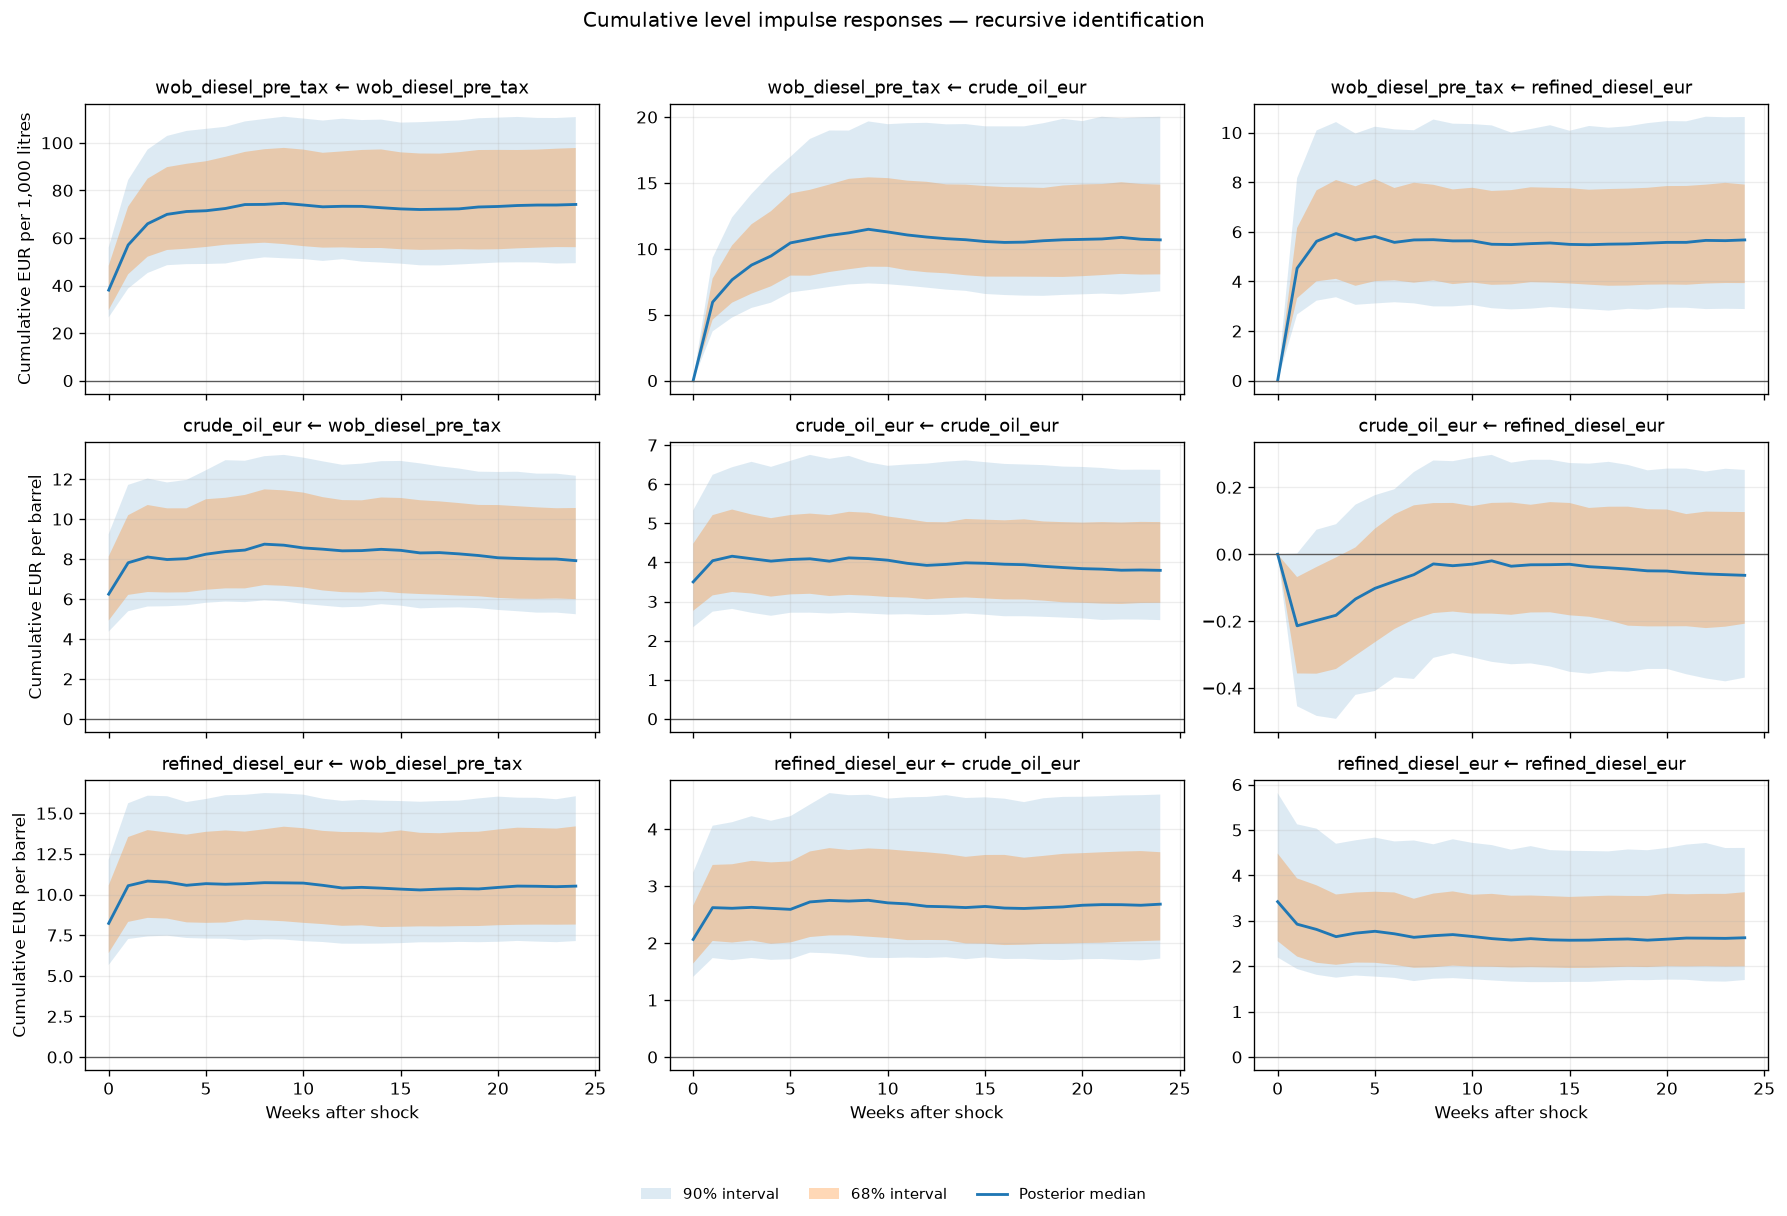

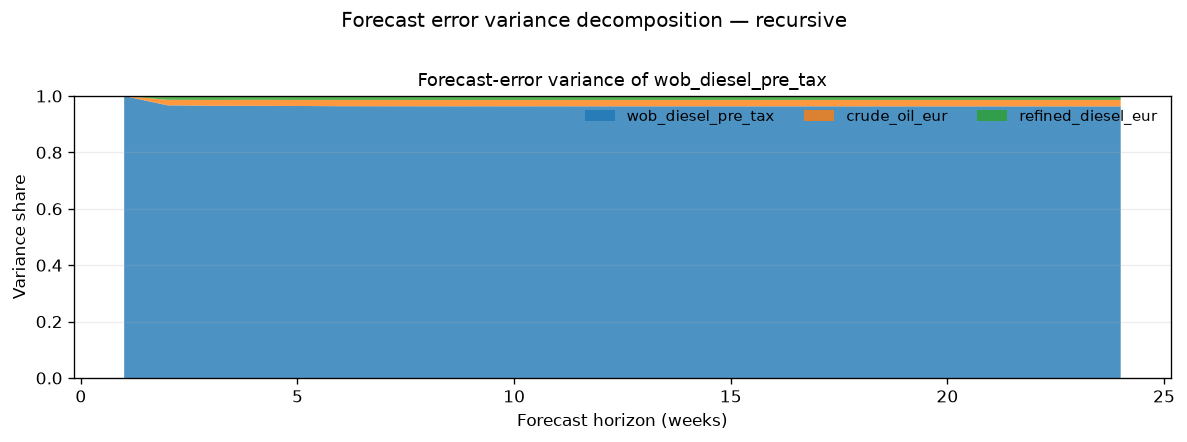

Maximum historical-decomposition reconstruction error: 1.563e-13


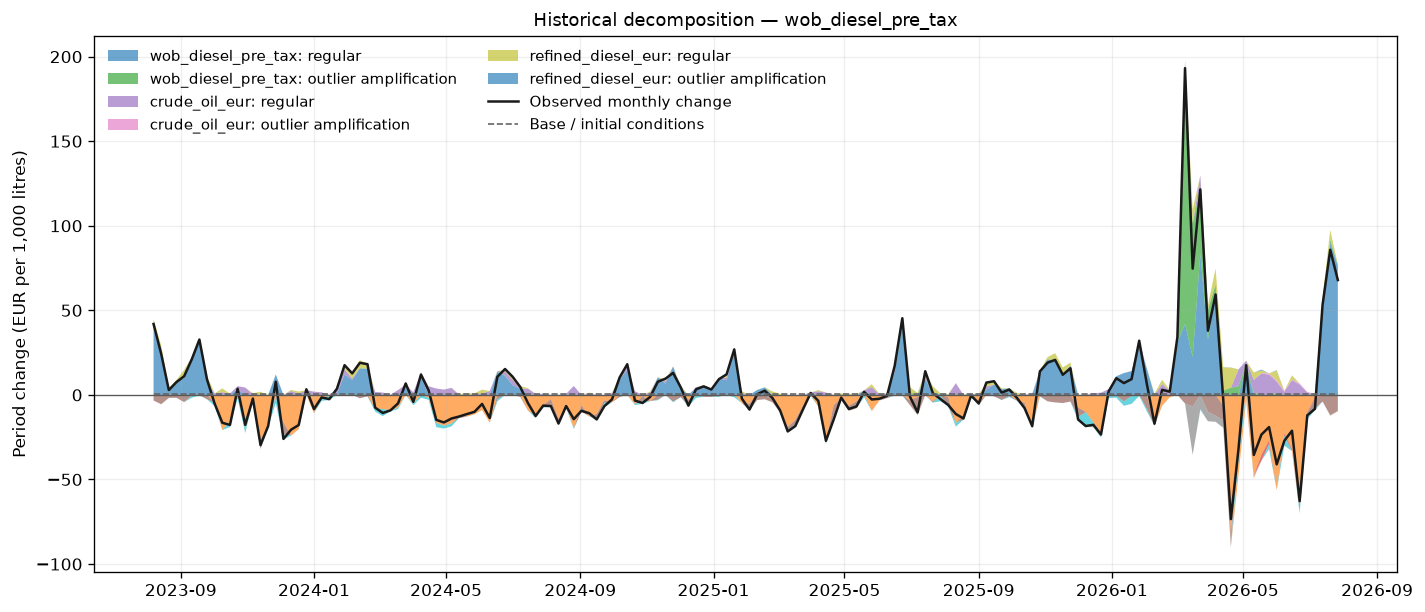

In [13]:
# Structural objects can be large. Use a reproducible posterior subset for plots.
structural_count = min(STRUCTURAL_DRAWS, result["n_draws"])
structural_index = np.linspace(
    0,
    result["n_draws"] - 1,
    structural_count,
    dtype=int,
)
structural_result = dict(result)
for key in (
    "B", "A", "log_variance", "phi", "outlier_scales",
    "outlier_indicators", "outlier_probabilities",
    "posterior_outlier_probability_draws", "spectral_radius", "log_likelihood",
    "completed_differences_draws", "missing_level_draws",
    "last_companion_state_draws",
):
    if key in result:
        structural_result[key] = np.asarray(result[key])[structural_index]
structural_result["n_draws"] = structural_count

irf = impulse_responses(
    structural_result,
    identification="recursive",
    horizon=24,
    shock_unit="structural_std",
)
plot_impulse_responses(irf, cumulative=True, units=UNITS)
plt.show()

fevd = forecast_error_variance_decomposition(
    structural_result,
    identification="recursive",
    horizon=24,
)
plot_fevd(fevd, responses=[TARGET])
plt.show()

hd = historical_decomposition(
    structural_result,
    identification="recursive",
    split_outlier_amplification=True,
)
print(f"Maximum historical-decomposition reconstruction error: {hd['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd,
    response=TARGET,
    last_obs=156,
    unit=UNITS[TARGET],
)
plt.show()

## 10. Forecast validation tests

In [14]:
base_level = np.asarray(result["prep"]["level_at_balanced_end"], dtype=float)
reconstructed_levels = (
    base_level[None, None, :]
    + np.cumsum(forecast_unconditional["diff_paths"], axis=1)
)
cumulative_error = float(np.max(np.abs(
    reconstructed_levels - forecast_unconditional["level_paths"]
)))

observed = levels.reindex(
    forecast_unconditional["path_dates"]
).to_numpy(dtype=float)
observation_errors = []
for j, variable in enumerate(VARIABLES):
    mask = np.isfinite(observed[:, j])
    if mask.any():
        observation_errors.append(float(np.max(np.abs(
            forecast_unconditional["level_paths"][:, mask, j]
            - observed[None, mask, j]
        ))))
observed_error = max(observation_errors, default=0.0)

crude_condition_error = float(np.max(np.abs(
    forecast_crude_up_10["future_level_paths"][:, :, VARIABLES.index("crude_oil_eur")]
    - crude_up_10[None, :]
)))
refined_condition_error = float(np.max(np.abs(
    forecast_refined_up_10["future_level_paths"][:, :, VARIABLES.index("refined_diesel_eur")]
    - refined_up_10[None, :]
)))

in_sample_observed_error = 0.0
if "completed_differences_draws" in result:
    completed = np.asarray(result["completed_differences_draws"], dtype=float)
    path_diffs = completed[:, P:, :]
    anchor = np.asarray(result["prep"]["augmentation_anchor_level"], dtype=float)
    reconstructed_in_sample = anchor[None, None, :] + np.cumsum(path_diffs, axis=1)
    observed_in_sample = result["prep"]["estimation_levels"].to_numpy(dtype=float)
    if np.isfinite(observed_in_sample).any():
        in_sample_observed_error = float(np.nanmax(np.abs(
            reconstructed_in_sample - observed_in_sample[None, :, :]
        )))

validation = pd.Series({
    "metadata frequency is weekly": result["metadata"]["frequency"] == "weekly",
    "DK interior data augmentation active": result["metadata"].get("requires_data_augmentation", False),
    "all processed dates are Mondays": bool((levels.index.dayofweek == 0).all()),
    "all future dates are Mondays": bool((forecast_unconditional["future_dates"].dayofweek == 0).all()),
    "forecast cumulative level identity error": cumulative_error,
    "maximum released ragged-level error": observed_error,
    "maximum released in-sample level error": in_sample_observed_error,
    "crude +10% condition error": crude_condition_error,
    "refined diesel +10% condition error": refined_condition_error,
    "retained unstable share": float(stability_diagnostics(result)["retained_unstable_share"]),
})
display(style_numeric_table(
    validation.to_frame("value"),
    caption="Weekly DK data-augmentation and forecast validation",
))

assert result["metadata"]["frequency"] == "weekly"
assert result["metadata"].get("requires_data_augmentation", False)
assert (levels.index.dayofweek == 0).all()
assert (forecast_unconditional["future_dates"].dayofweek == 0).all()
assert cumulative_error < 1e-8
assert observed_error < 1e-8
assert in_sample_observed_error < 1e-8
assert crude_condition_error < 1e-8
assert refined_condition_error < 1e-8
assert stability_diagnostics(result)["retained_unstable_share"] == 0.0

print("All weekly calendar, interior-DK, ragged-edge and conditioning checks passed.")


,value
metadata frequency is weekly,True
DK interior data augmentation active,True
all processed dates are Mondays,True
all future dates are Mondays,True
forecast cumulative level identity error,0.0
maximum released ragged-level error,0.0
maximum released in-sample level error,0.0
crude +10% condition error,0.0
refined diesel +10% condition error,0.0
retained unstable share,0.0


All weekly calendar, interior-DK, ragged-edge and conditioning checks passed.
